# Notebook 5 — Trading Signals & Backtest (CVAE-driven)

This notebook extends the AEMM framework of Sokol (2022) with **two trading
strategies** on the 2s10s swap slope, both built on the CVAE residuals from NB3.

## Strategies

**Strategy A — CVAE Slope Residual Mean-Reversion**
Signal = (actual 2s10s slope) − (CVAE-reconstructed 2s10s slope), z-scored.
Rationale: when the actual slope deviates from the CVAE's "fair value"
reconstruction, the deviation tends to mean-revert.

**Strategy B — CVAE z₂ Latent Shape Mean-Reversion**
Signal = z-score of the CVAE's second latent factor z₂.
Rationale: in a currency-conditioned CVAE, z₂ encodes pure curve shape; an
extreme z₂ flags an unusual slope/curvature configuration.

## P&L conventions
For each strategy we report **two P&L conventions**:
1. **Raw bp P&L**: `pos × Δ(10Y − 2Y)` in bp. Treats the slope as a tradable.
   Simple, but ignores the difference in DV01 between the two legs.
2. **DV01-weighted P&L**: a true 2s10s spread trade where the 2Y notional is
   scaled so that both legs have equal DV01. The position becomes immune to
   parallel curve shifts.

## Benchmarks
Two benchmarks are run alongside each strategy:
- **Naive**: z-score of the raw slope (no model)
- **Nelson-Siegel**: z-score of the NS residual on the slope

## Hyperparameter regimes
1. **Fixed**: entry_z=1.0, exit_z=0.3, lookback=60d, tc=0.5bp (conservative defaults)
2. **Optimised**: hyperparameters tuned on the train set, evaluated on the test set

## Honest reporting

> ⚠️ **Disclaimer**: with ~3 years of data and a 70/30 split, the OOS window is
> ~230 business days (~9 months). Sharpe ratios computed on this short window
> are **illustrative, not statistically significant**. The point of this
> notebook is to demonstrate the *methodology* of building a model-driven swap
> strategy and to compare CVAE signals against NS and naive benchmarks on the
> same OOS window.

## References
- Sokol, A. (2022). *Autoencoder Market Models for Interest Rates.* SSRN 4300756.
- Lombard Odier IM (2022). *Exploiting yield-curve dynamics in hiking cycles* — uses 2s10s flatteners and 2s10s30s butterflies as duration-neutral curve trades. [link](https://am.lombardodier.com/contents/news/investment-viewpoints/2022/january/exploiting-yield-curve-dynamics.html)
- CME Group. *Swap Rate Curve Strategies with Deliverable Interest Rate Swap Futures* — DV01-weighting conventions for swap curve spreads. [link](https://www.cmegroup.com/trading/interest-rates/files/dsf-swap-rate-curve-spreads.pdf)
- Clarus FT. *Mechanics and Definitions of Spread and Butterfly Swap Packages* — formal DV01 ratio for the short leg of a swap spread. [link](https://www.clarusft.com/mechanics-and-definitions-of-spread-and-butterfly-swap-packages/)
- Montréal Exchange (2021). *Understanding 2-5-10 Butterfly Trades in Futures* — DV01-neutral, cash-neutral, and regression-weighted constructions.
- CME Group. *Yield Curve Spread Trades: Opportunities & Applications* — return estimation via DV01 × spread change.


## 0 — Imports & Setup

In [14]:
import pickle
import warnings
from pathlib import Path
from typing import Dict, Tuple, Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

FIG_DIR = Path("figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR = Path("results"); RES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1 — Load NB3 outputs

Everything we need is already in `results/vae_results_extended.pkl`:
the trained CVAE state dict, the list of currencies, the train/test cutoff,
the NS results (for the benchmark), and the normalisation constants.

In [15]:
# ── Load the CVAE training results from NB3 ──────────────────────
with open(RES_DIR / "vae_results_extended.pkl", "rb") as f:
    vae_data = pickle.load(f)

cfg            = vae_data["config"]
CURRENCIES     = list(cfg["currencies"])
N_CCY          = len(CURRENCIES)
CCY_TO_IDX     = {c: i for i, c in enumerate(CURRENCIES)}
TARGET_TENORS  = list(cfg["target_tenors"])
S_MIN, S_MAX   = float(cfg["S_MIN"]), float(cfg["S_MAX"])
BP_PER_UNIT    = float(cfg["bp_per_unit"])
TRAIN_CUTOFF   = pd.Timestamp(cfg["train_cutoff"])
SEED           = int(cfg["seed"])

torch.manual_seed(SEED); np.random.seed(SEED)

print(f"Currencies     : {CURRENCIES}")
print(f"Tenors         : {TARGET_TENORS}")
print(f"Train cutoff   : {TRAIN_CUTOFF.date()}")
print(f"Normalisation  : [{S_MIN:.2f}, {S_MAX:.2f}]")

Currencies     : ['AUD', 'CAD', 'DKK', 'EUR', 'GBP', 'JPY', 'USD']
Tenors         : [2, 3, 5, 10, 15, 20, 30]
Train cutoff   : 2025-03-31
Normalisation  : [-0.05, 0.25]


In [16]:
# ── Reload swap data from CSV (same source as NB3) ───────────────
df_long = pd.read_csv("data/df_multi.csv", parse_dates=["Date"])
EXCLUDE_CURRENCIES = set(df_long["currency"].unique()) - set(CURRENCIES)
df_long = df_long[~df_long["currency"].isin(EXCLUDE_CURRENCIES)].copy()

TENOR_COLS = [str(t) for t in TARGET_TENORS]
swap_aligned: dict[str, pd.DataFrame] = {}
for ccy in CURRENCIES:
    sub = (df_long[df_long["currency"] == ccy]
           .set_index("Date").sort_index()[TENOR_COLS].copy())
    sub.columns = TARGET_TENORS
    swap_aligned[ccy] = sub

dates_ref = swap_aligned[CURRENCIES[0]].index
print(f"Loaded {len(CURRENCIES)} currencies, {len(dates_ref)} dates "
      f"({dates_ref.min().date()} → {dates_ref.max().date()})")

Loaded 7 currencies, 774 dates (2023-01-30 → 2026-01-15)


## 2 — Reconstruct the CVAE from NB3 weights

We re-instantiate the same CVAE architecture as NB3 (Table 3 of Sokol 2022)
and load the trained weights. No retraining.

In [17]:
class CVAE(nn.Module):
    def __init__(self, input_dim: int = 7, latent_dim: int = 2, n_currencies: int = N_CCY):
        super().__init__()
        self.input_dim, self.latent_dim, self.n_currencies = input_dim, latent_dim, n_currencies
        enc_in = input_dim + n_currencies
        dec_in = latent_dim + n_currencies
        self.encoder = nn.Sequential(
            nn.Linear(enc_in, enc_in - 1), nn.Tanh(),
            nn.Linear(enc_in - 1, 2 * latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, input_dim), nn.Tanh(),
            nn.Linear(input_dim, input_dim), nn.Tanh(),
            nn.Linear(input_dim, input_dim), nn.Sigmoid())
    def encode(self, x, y):
        h = self.encoder(torch.cat([x, y], dim=-1))
        return h[:, :self.latent_dim], h[:, self.latent_dim:]
    def decode(self, z, y):
        return self.decoder(torch.cat([z, y], dim=-1))
    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        return self.decode(mu, y), mu, logvar  # deterministic at eval

cvae = CVAE(input_dim=len(TARGET_TENORS), latent_dim=2, n_currencies=N_CCY).to(device)
cvae.load_state_dict(vae_data["cvae_state"])
cvae.eval()
print(f"CVAE reloaded ({sum(p.numel() for p in cvae.parameters()):,} params)")

CVAE reloaded (433 params)


## 3 — Helpers: normalisation, CVAE fair-value, NS fair-value

In [18]:
def normalize_rates(r: np.ndarray)   -> np.ndarray:
    return np.clip((r - S_MIN) / (S_MAX - S_MIN), 0.0, 1.0)

def denormalize_rates(x: np.ndarray) -> np.ndarray:
    return x * (S_MAX - S_MIN) + S_MIN

def cvae_fair_value(df: pd.DataFrame, ccy: str) -> pd.DataFrame:
    """Run the CVAE on a currency and return the reconstructed curves (decimal)."""
    rates = df.values.astype(np.float32)
    X = torch.from_numpy(normalize_rates(rates).astype(np.float32)).to(device)
    oh = np.zeros((len(rates), N_CCY), dtype=np.float32)
    oh[:, CCY_TO_IDX[ccy]] = 1.0
    Y = torch.from_numpy(oh).to(device)
    with torch.no_grad():
        Xrec, mu, _ = cvae(X, Y)
    rec = denormalize_rates(Xrec.cpu().numpy())
    z   = mu.cpu().numpy()
    out = pd.DataFrame(rec, index=df.index, columns=TARGET_TENORS)
    out["z1"] = z[:, 0]
    out["z2"] = z[:, 1]
    return out

# ── Nelson-Siegel fair value (same as NB3) ───────────────────────
class NelsonSiegel:
    def __init__(self, lam: float = 1.5):
        self.lam = lam
    def basis(self, tau):
        tau = np.asarray(tau, dtype=float)
        tl  = np.maximum(tau / self.lam, 1e-10)
        f1  = np.ones_like(tau)
        f2  = (1 - np.exp(-tl)) / tl
        f3  = f2 - np.exp(-tl)
        return np.column_stack([f1, f2, f3])
    def fit_predict(self, tau, rates_matrix):
        X = self.basis(tau)
        n_obs = rates_matrix.shape[0]
        fitted = np.zeros_like(rates_matrix)
        for i in range(n_obs):
            beta, *_ = np.linalg.lstsq(X, rates_matrix[i], rcond=None)
            fitted[i] = X @ beta
        return fitted

ns_model = NelsonSiegel(lam=1.5)
tenors_arr = np.array(TARGET_TENORS, dtype=float)

def ns_fair_value(df: pd.DataFrame) -> pd.DataFrame:
    fitted = ns_model.fit_predict(tenors_arr, df.values.astype(float))
    return pd.DataFrame(fitted, index=df.index, columns=TARGET_TENORS)

## 4 — Build the signal panel for every currency

For each currency we compute, on the FULL date index:
- the actual 2s10s slope (bp)
- the CVAE fair-value slope (bp) and its residual (= signal A)
- the NS fair-value slope (bp) and its residual (NS benchmark)
- the CVAE latent factor z₂ (signal B)

The z-scoring (rolling mean/std) happens later, inside the backtest loop, so
that the lookback parameter can be varied during optimisation.

In [19]:
IDX_2Y, IDX_10Y = TARGET_TENORS.index(2), TARGET_TENORS.index(10)

panels: dict[str, pd.DataFrame] = {}
for ccy in CURRENCIES:
    df  = swap_aligned[ccy]
    cv  = cvae_fair_value(df, ccy)
    nsf = ns_fair_value(df)

    slope_actual = (df[10]   - df[2])   * BP_PER_UNIT
    slope_cvae   = (cv[10]   - cv[2])   * BP_PER_UNIT
    slope_ns     = (nsf[10]  - nsf[2])  * BP_PER_UNIT

    p = pd.DataFrame(index=df.index)
    p["rate_2Y"]      = df[2]
    p["rate_10Y"]     = df[10]
    p["slope_bp"]     = slope_actual
    p["slope_chg_bp"] = slope_actual.diff()
    p["cvae_slope_bp"]= slope_cvae
    p["cvae_resid_bp"]= slope_actual - slope_cvae
    p["ns_slope_bp"]  = slope_ns
    p["ns_resid_bp"]  = slope_actual - slope_ns
    p["z2"]           = cv["z2"]
    panels[ccy] = p

print(f"Built panels for {len(panels)} currencies")
panels[CURRENCIES[0]].tail(3)

Built panels for 7 currencies


,rate_2Y,rate_10Y,slope_bp,slope_chg_bp,cvae_slope_bp,cvae_resid_bp,ns_slope_bp,ns_resid_bp,z2
Date,,,,,,,,,
2026-01-13,0.03969,0.045130,54.40,4.00,54.210052,0.189948,54.058036,0.341964,-0.054663
2026-01-14,0.03945,0.044637,51.87,-2.53,52.427277,-0.557277,51.561118,0.308882,-0.068952
2026-01-15,0.03980,0.044840,50.40,-1.47,50.579830,-0.179830,50.056944,0.343056,-0.074401


## 5 — Backtest engine

A single function handles all four (signal × P&L convention) combinations.
A few design choices worth noting:

**DV01 approximation.** For a par swap with yield close to its coupon, the
DV01 of the fixed leg is approximately equal to the modified duration times
the notional. We use the simple closed-form approximation
$\text{DV01}(T, y) \approx \frac{1}{y}\big(1 - \frac{1}{(1+y)^T}\big) \cdot 10^{-4}$
per unit notional, which is the standard "annuity" approximation for a par
swap (CME Group, *Swap Rate Curve Strategies*, p. 6). To trade DV01-neutral
2s10s, we set the 2Y notional to `DV01_10Y / DV01_2Y` per unit of 10Y notional
— this is the conventional spread weighting in Clarus FT and CME Group docs.

**Position sign convention.**
- `+1` = **steepener**: *pay* 10Y fixed (≡ short 10Y bond), *receive* 2Y fixed (≡ long 2Y bond)
- `-1` = **flattener**: *receive* 10Y fixed (≡ long 10Y bond), *pay* 2Y fixed (≡ short 2Y bond)
- A steepener profits when (10Y − 2Y) **widens** (10Y rises more than 2Y, or 2Y falls more than 10Y).

**Mean-reversion logic.** When the signal z-score is high (slope too steep
relative to fair value), we enter a flattener (pos = -1) to fade the deviation.

In [ ]:
def dv01_per_unit_notional(tenor_years: float, yield_dec: float) -> float:
    """Annuity approximation of par-swap DV01 per 1 unit of notional.

    DV01 ≈ A(T,y) × 1e-4   where   A(T,y) = (1 - (1+y)^{-T}) / y
    Source: CME Group, 'Swap Rate Curve Strategies with DSF futures', p.6.

    Valid for y > -1. Uses the analytic y→0 limit (A → T) for |y| < 1e-8
    to preserve accuracy on near-zero and mildly negative rates (EUR/CHF
    during the negative-rate era).
    """
    y = float(yield_dec)
    if abs(y) < 1e-8:
        annuity = float(tenor_years)
    else:
        annuity = (1.0 - (1.0 + y) ** (-tenor_years)) / y
    return annuity * 1e-4

def compute_zscore(series: pd.Series, lookback: int) -> pd.Series:
    rm = series.rolling(lookback, min_periods=lookback // 2).mean()
    rs = series.rolling(lookback, min_periods=lookback // 2).std().clip(lower=1e-6)
    return (series - rm) / rs

def build_positions(zscore: pd.Series, entry_z: float, exit_z: float) -> pd.Series:
    """Hysteresis-based position from a z-score.

    +1 = steepener  (z << 0  → slope too flat → bet it widens)
    -1 = flattener  (z >> 0  → slope too steep → bet it narrows)
     0 = flat
    """
    pos = np.zeros(len(zscore))
    prev = 0.0
    z = zscore.values
    for i in range(len(z)):
        zi = z[i]
        if np.isnan(zi):
            pos[i] = prev; continue
        if   zi >  entry_z: prev = -1.0   # flattener
        elif zi < -entry_z: prev = +1.0   # steepener
        elif abs(zi) < exit_z: prev = 0.0
        pos[i] = prev
    return pd.Series(pos, index=zscore.index)

def backtest(
    panel: pd.DataFrame,
    signal: pd.Series,
    *,
    entry_z: float = 1.0,
    exit_z:  float = 0.3,
    lookback: int = 60,
    tc_bp:   float = 0.5,
    pnl_mode: str = "raw_bp",   # 'raw_bp' or 'dv01'
    notional_10y: float = 1e7,  # for dv01 mode only: 10M of 10Y notional
) -> pd.DataFrame:
    """Generic backtest. Returns a DataFrame with positions and P&L."""
    z   = compute_zscore(signal, lookback)
    pos = build_positions(z, entry_z, exit_z)
    pos_lag = pos.shift(1).fillna(0.0)   # trade at next bar's open

    if pnl_mode == "raw_bp":
        # Simple: P&L = pos × Δ(10Y − 2Y)   in bp.
        pnl_per_step = pos_lag * panel["slope_chg_bp"]
        # Transaction cost: tc_bp per unit of position change
        tc = pos_lag.diff().abs().fillna(0.0) * tc_bp
        net = pnl_per_step - tc
        unit = "bp"

    elif pnl_mode == "dv01":
        # True DV01-weighted spread trade: both legs sized so DV01_2Y == DV01_10Y
        # (the 2Y notional is rescaled daily so the trade is insensitive to
        # parallel shifts).
        d2  = panel["rate_2Y"].apply(lambda y: dv01_per_unit_notional(2.0,  y))
        d10 = panel["rate_10Y"].apply(lambda y: dv01_per_unit_notional(10.0, y))
        notional_2y = notional_10y * (d10 / d2)

        dr2  = panel["rate_2Y"].diff()
        dr10 = panel["rate_10Y"].diff()

        # Steepener (pos = +1) in swap convention: pay 10Y fixed (≡ short 10Y
        # bond, profits when r_10Y rises), receive 2Y fixed (≡ long 2Y bond,
        # profits when r_2Y falls). So spread P&L per unit position is:
        #     +dr_10Y × N_10Y × DV01_10Y  −  dr_2Y × N_2Y × DV01_2Y
        # (factor 1e4 converts DV01_per_unit [$/bp/unit-notional] back to
        # $/unit-rate because dr is stored in decimal form).
        leg10_dollar = +dr10 * notional_10y * d10 * 1e4
        leg2_dollar  = -dr2  * notional_2y  * d2  * 1e4
        spread_pnl_dollar = leg10_dollar + leg2_dollar
        pnl_per_step = pos_lag * spread_pnl_dollar

        # TC: tc_bp is the round-trip cost of a full spread flip (both legs),
        # so no extra factor-of-2 is applied here.
        tc_dollar = pos_lag.diff().abs().fillna(0.0) * (
            tc_bp * (notional_10y * d10 + notional_2y * d2)
        )
        net = pnl_per_step - tc_dollar
        unit = "USD"
    else:
        raise ValueError(f"Unknown pnl_mode {pnl_mode}")

    out = pd.DataFrame({
        "signal":    signal,
        "zscore":    z,
        "position":  pos,
        "pnl":       net,
        "cum_pnl":   net.cumsum(),
    }, index=panel.index)
    out.attrs["unit"] = unit
    return out


## 6 — Performance metrics

In [21]:
ANN = 252  # business days per year

def perf_stats(pnl: pd.Series, label: str = "") -> dict:
    pnl = pnl.dropna()
    if len(pnl) == 0 or pnl.std() == 0:
        return {"label": label, "N": len(pnl), "Total": 0.0, "Ann": 0.0,
                "Vol": 0.0, "Sharpe": 0.0, "MaxDD": 0.0, "HitRate": 0.0,
                "NumTrades": 0}
    cum = pnl.cumsum()
    peak = cum.expanding().max()
    dd = (cum - peak).min()
    trades = pnl[pnl != 0]
    return {
        "label":     label,
        "N":         len(pnl),
        "Total":     float(cum.iloc[-1]),
        "Ann":       float(pnl.mean() * ANN),
        "Vol":       float(pnl.std() * np.sqrt(ANN)),
        "Sharpe":    float(pnl.mean() / pnl.std() * np.sqrt(ANN)),
        "MaxDD":     float(dd),
        "HitRate":   float((trades > 0).mean()) if len(trades) else 0.0,
        "NumTrades": int(len(trades)),
    }

## 7 — Run all combos with FIXED hyperparameters

For every currency we run six backtests:
- Strategy A (CVAE residual)  × {raw bp, DV01-weighted}
- Benchmark NS (NS residual)  × {raw bp, DV01-weighted}
- Benchmark Naive (raw slope) × {raw bp, DV01-weighted}

And similarly for Strategy B (z₂).
All restricted to the OOS window (post `TRAIN_CUTOFF`).

In [22]:
HP_FIXED = dict(entry_z=1.0, exit_z=0.3, lookback=60, tc_bp=0.5)

SIGNAL_LIBRARY = {
    "CVAE_resid": lambda p: p["cvae_resid_bp"],
    "NS_resid":   lambda p: p["ns_resid_bp"],
    "Naive":      lambda p: p["slope_bp"],
    "CVAE_z2":    lambda p: p["z2"],
}

def run_all(panels, hp, label_suffix=""):
    rows = []
    bt_store = {}  # (ccy, sig_name, pnl_mode) -> backtest df
    for ccy in CURRENCIES:
        p = panels[ccy]
        oos_mask = p.index > TRAIN_CUTOFF
        for sig_name, sig_fn in SIGNAL_LIBRARY.items():
            sig = sig_fn(p)
            for pnl_mode in ("raw_bp", "dv01"):
                bt = backtest(p, sig, pnl_mode=pnl_mode, **hp)
                bt_oos = bt.loc[oos_mask]
                stats = perf_stats(bt_oos["pnl"], label=f"{ccy}|{sig_name}|{pnl_mode}")
                stats["currency"] = ccy
                stats["signal"]   = sig_name
                stats["pnl_mode"] = pnl_mode
                stats["regime"]   = label_suffix
                rows.append(stats)
                bt_store[(ccy, sig_name, pnl_mode)] = bt
    return pd.DataFrame(rows), bt_store

print("=" * 72)
print("FIXED HYPERPARAMETERS")
print(f"  entry_z={HP_FIXED['entry_z']}, exit_z={HP_FIXED['exit_z']}, "
      f"lookback={HP_FIXED['lookback']}, tc_bp={HP_FIXED['tc_bp']}")
print("=" * 72)

df_fixed, bt_fixed = run_all(panels, HP_FIXED, label_suffix="fixed")
print(f"\nRan {len(df_fixed)} backtests on OOS window "
      f"({(dates_ref > TRAIN_CUTOFF).sum()} business days)\n")

# Pretty per-signal summary across currencies
def summary_by_signal(df, pnl_mode):
    sub = df[df["pnl_mode"] == pnl_mode]
    return (sub.groupby("signal")[["Sharpe", "Total", "MaxDD", "HitRate", "NumTrades"]]
              .mean().round(2).sort_values("Sharpe", ascending=False))

print("Average performance across all currencies — RAW BP:")
print(summary_by_signal(df_fixed, "raw_bp"))
print("\nAverage performance across all currencies — DV01:")
print(summary_by_signal(df_fixed, "dv01"))

FIXED HYPERPARAMETERS
  entry_z=1.0, exit_z=0.3, lookback=60, tc_bp=0.5

Ran 56 backtests on OOS window (208 business days)

Average performance across all currencies — RAW BP:
            Sharpe  Total  MaxDD  HitRate  NumTrades
signal                                              
CVAE_resid    1.69  79.43 -21.01     0.49     154.00
Naive         0.68  41.32 -27.59     0.51     149.29
CVAE_z2       0.27  32.47 -33.28     0.50     158.43
NS_resid     -0.04 -20.48 -49.92     0.45     134.29

Average performance across all currencies — DV01:
            Sharpe      Total      MaxDD  HitRate  NumTrades
signal                                                      
CVAE_resid    1.24  536502.37 -197244.13     0.48     154.00
Naive         0.42  255426.08 -242234.27     0.51     149.29
CVAE_z2       0.05  187630.58 -298661.99     0.49     158.43
NS_resid     -0.55 -292501.92 -483258.05     0.44     134.29


## 8 — Per-currency tables (fixed regime)

In [23]:
def per_currency_table(df, pnl_mode):
    sub = df[df["pnl_mode"] == pnl_mode]
    pivot = sub.pivot_table(index="currency", columns="signal", values="Sharpe").round(2)
    cols_order = ["Naive", "NS_resid", "CVAE_resid", "CVAE_z2"]
    pivot = pivot[[c for c in cols_order if c in pivot.columns]]
    return pivot

print("Sharpe ratios — RAW BP P&L (OOS only)")
print(per_currency_table(df_fixed, "raw_bp"))
print()
print("Sharpe ratios — DV01-weighted P&L (OOS only)")
print(per_currency_table(df_fixed, "dv01"))

Sharpe ratios — RAW BP P&L (OOS only)
signal    Naive  NS_resid  CVAE_resid  CVAE_z2
currency                                      
AUD        2.83     -3.32        3.77     3.37
CAD        1.78      1.69        2.79     0.95
DKK        0.52     -0.76        2.72     0.02
EUR       -0.45      1.72        1.69    -1.78
GBP       -0.08     -0.92        0.10     0.12
JPY        0.28      0.42        0.58    -0.80
USD       -0.11      0.90        0.18     0.03

Sharpe ratios — DV01-weighted P&L (OOS only)
signal    Naive  NS_resid  CVAE_resid  CVAE_z2
currency                                      
AUD        2.55     -3.70        3.47     3.10
CAD        1.50      1.11        2.28     0.86
DKK        0.26     -1.14        2.25    -0.15
EUR       -0.68      0.19        0.54    -2.12
GBP       -0.29     -1.19       -0.19    -0.08
JPY       -0.12      0.19        0.18    -1.02
USD       -0.31      0.68        0.13    -0.22


## 9 — Plot: cumulative P&L per currency, both signals vs benchmarks (fixed regime, raw bp)

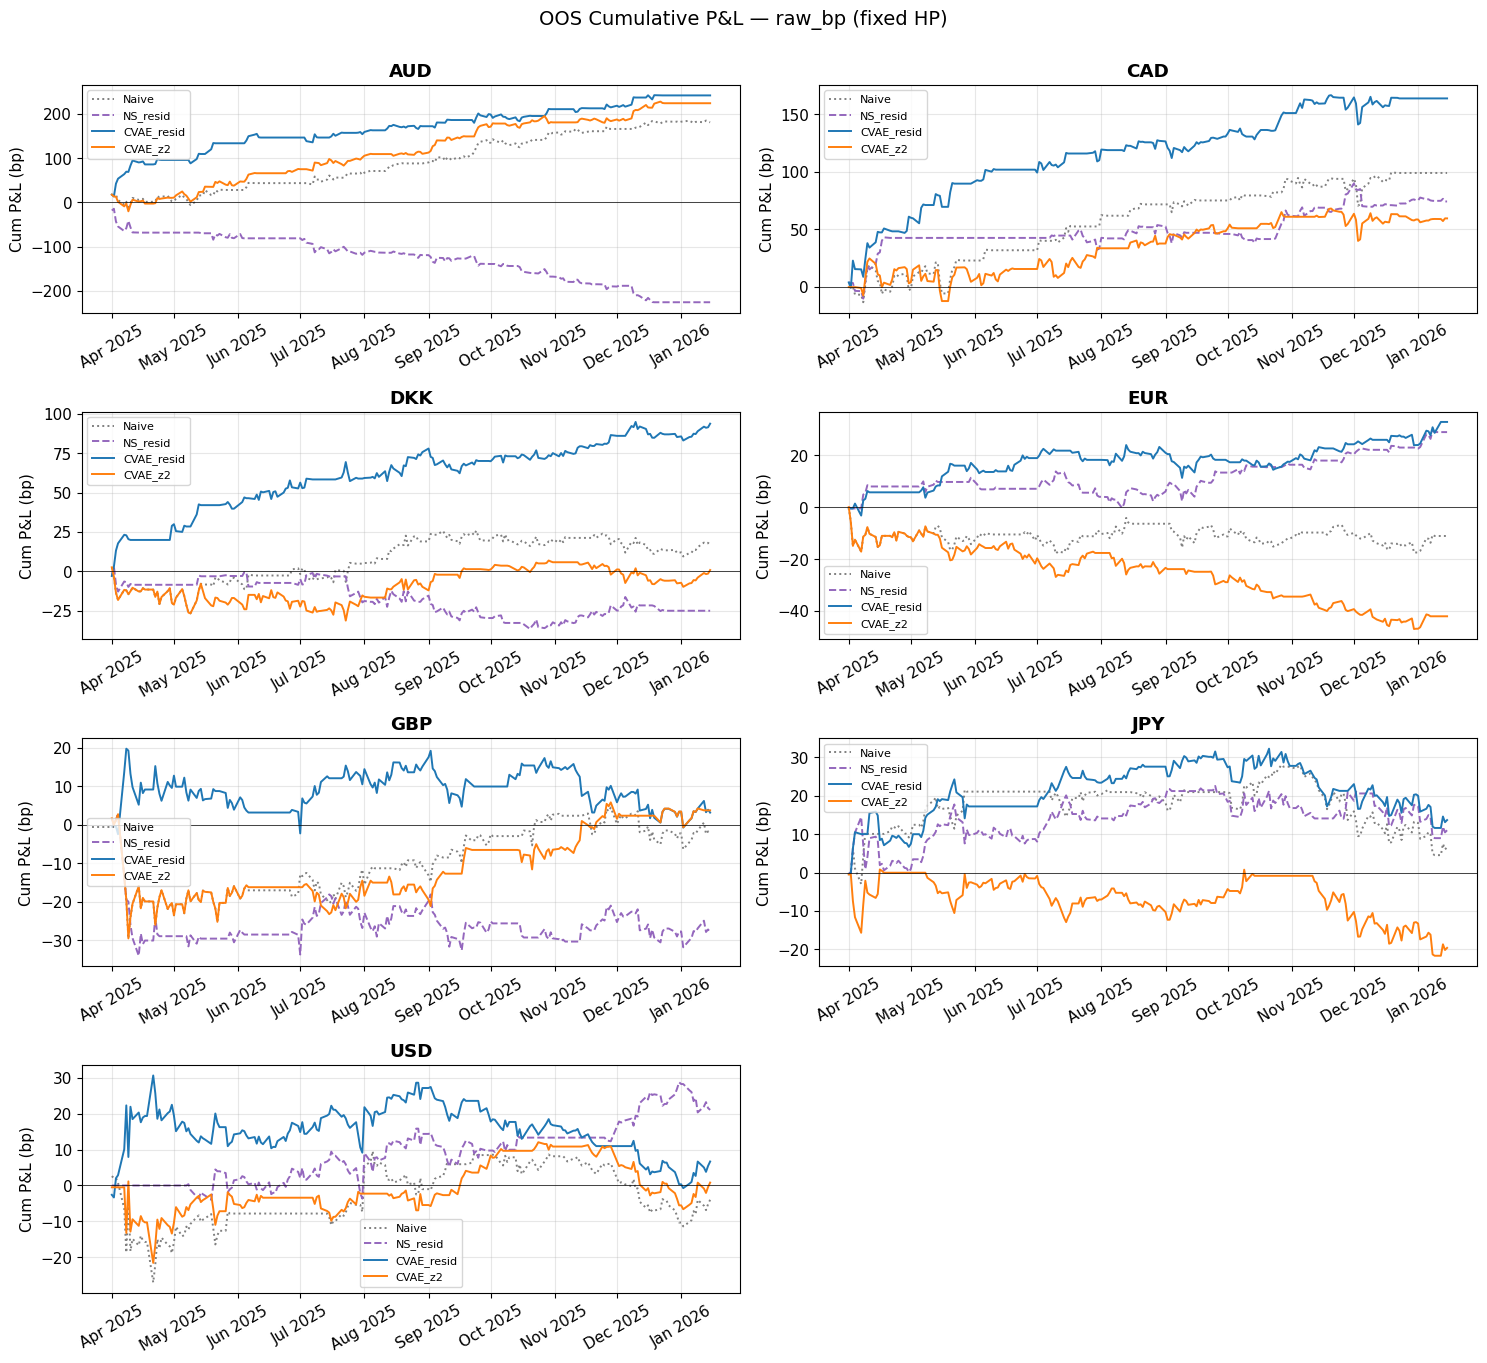

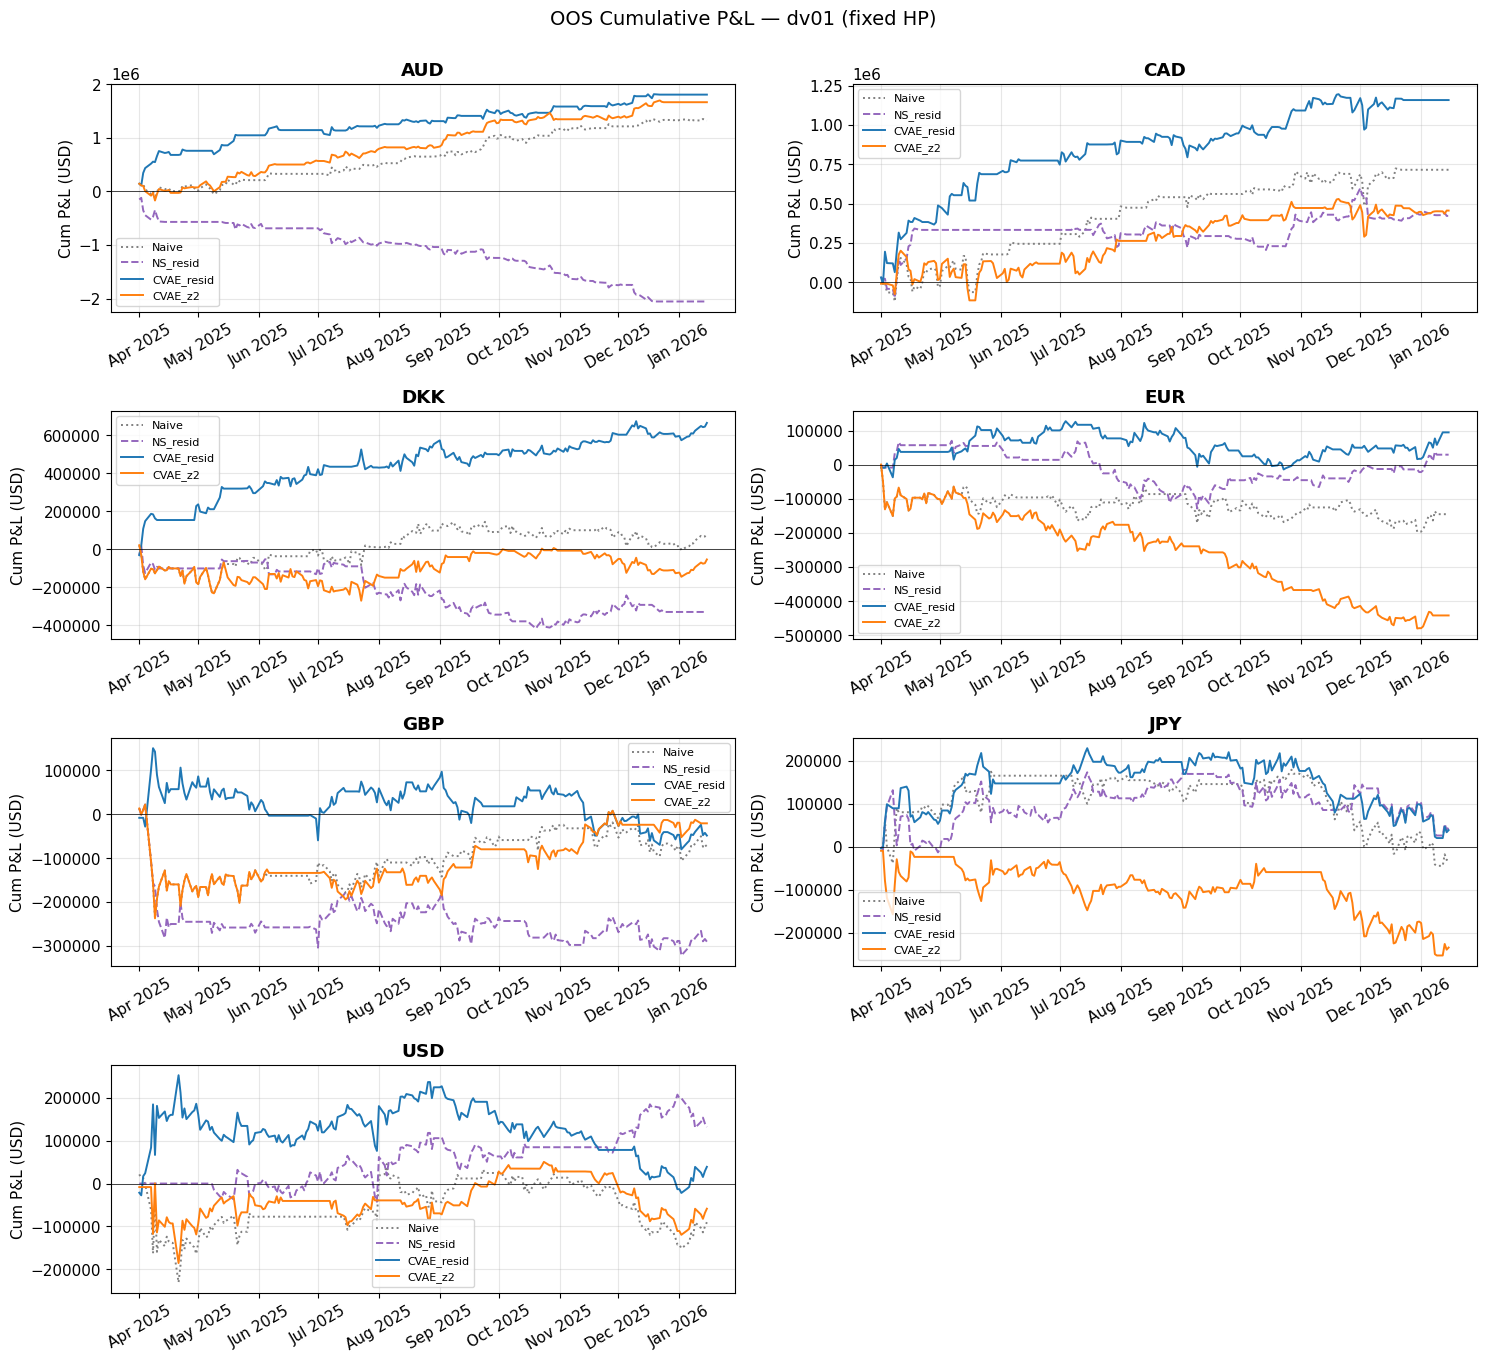

In [24]:
def plot_cum_pnl(bt_store, pnl_mode, title_suffix=""):
    n = len(CURRENCIES)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.4 * rows), squeeze=False)

    colors = {"Naive": "gray", "NS_resid": "tab:purple",
              "CVAE_resid": "tab:blue", "CVAE_z2": "tab:orange"}
    styles = {"Naive": ":", "NS_resid": "--", "CVAE_resid": "-", "CVAE_z2": "-"}

    for k, ccy in enumerate(CURRENCIES):
        ax = axes[k // cols, k % cols]
        for sig_name in ["Naive", "NS_resid", "CVAE_resid", "CVAE_z2"]:
            bt = bt_store.get((ccy, sig_name, pnl_mode))
            if bt is None:
                continue
            oos = bt.loc[bt.index > TRAIN_CUTOFF, "pnl"].cumsum()
            ax.plot(oos.index, oos.values, label=sig_name,
                    color=colors[sig_name], linestyle=styles[sig_name], lw=1.4)
        ax.axhline(0, color="black", lw=0.5)
        ax.set_title(f"{ccy}", fontweight="bold")
        ax.set_ylabel(f"Cum P&L ({bt.attrs['unit']})")
        ax.legend(fontsize=8, loc="best")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax.tick_params(axis="x", rotation=30)

    for k in range(n, rows * cols):
        axes[k // cols, k % cols].set_visible(False)

    fig.suptitle(f"OOS Cumulative P&L — {pnl_mode}{title_suffix}", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig_19_oos_{pnl_mode}{title_suffix.replace(' ', '_')}.png",
                dpi=140, bbox_inches="tight")
    plt.show()

plot_cum_pnl(bt_fixed, "raw_bp", title_suffix=" (fixed HP)")
plot_cum_pnl(bt_fixed, "dv01",   title_suffix=" (fixed HP)")

## 10 — Equally-weighted portfolio across all currencies (fixed regime)

In [25]:
def portfolio_pnl(bt_store, sig_name, pnl_mode):
    pnl_list = []
    for ccy in CURRENCIES:
        bt = bt_store.get((ccy, sig_name, pnl_mode))
        if bt is None: continue
        oos = bt.loc[bt.index > TRAIN_CUTOFF, "pnl"]
        pnl_list.append(oos.rename(ccy))
    if not pnl_list:
        return pd.Series(dtype=float)
    M = pd.concat(pnl_list, axis=1).fillna(0.0)
    return M.mean(axis=1)  # equal-weight

port_rows = []
for sig_name in SIGNAL_LIBRARY:
    for pnl_mode in ("raw_bp", "dv01"):
        pnl = portfolio_pnl(bt_fixed, sig_name, pnl_mode)
        s = perf_stats(pnl, label=f"PORT|{sig_name}|{pnl_mode}")
        s.update(signal=sig_name, pnl_mode=pnl_mode, regime="fixed")
        port_rows.append(s)
df_port_fixed = pd.DataFrame(port_rows)

print("Equal-weight portfolio across currencies (FIXED HP) — RAW BP")
print(df_port_fixed[df_port_fixed["pnl_mode"] == "raw_bp"]
      .set_index("signal")[["Total", "Ann", "Vol", "Sharpe", "MaxDD", "HitRate"]]
      .round(2))
print()
print("Equal-weight portfolio across currencies (FIXED HP) — DV01")
print(df_port_fixed[df_port_fixed["pnl_mode"] == "dv01"]
      .set_index("signal")[["Total", "Ann", "Vol", "Sharpe", "MaxDD", "HitRate"]]
      .round(2))

Equal-weight portfolio across currencies (FIXED HP) — RAW BP
            Total    Ann    Vol  Sharpe  MaxDD  HitRate
signal                                                 
CVAE_resid  79.43  96.23  24.12    3.99  -5.86     0.56
NS_resid   -20.48 -24.81  18.03   -1.38 -19.66     0.48
Naive       41.32  50.06  23.00    2.18 -13.32     0.54
CVAE_z2     32.47  39.34  23.42    1.68 -13.55     0.51

Equal-weight portfolio across currencies (FIXED HP) — DV01
                Total        Ann        Vol  Sharpe      MaxDD  HitRate
signal                                                                 
CVAE_resid  536502.37  649993.25  202166.23    3.22  -51596.06     0.54
NS_resid   -292501.92 -354377.33  151299.21   -2.34 -280446.33     0.46
Naive       255426.08  309458.52  193804.45    1.60 -114874.83     0.53
CVAE_z2     187630.58  227321.67  197142.25    1.15 -117096.77     0.50


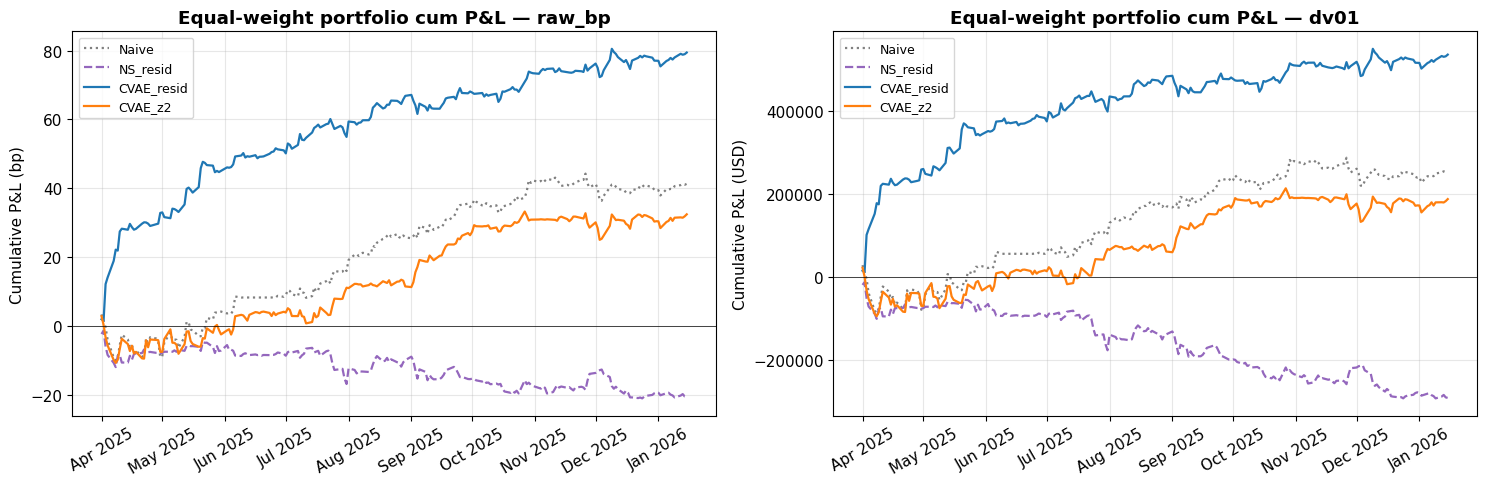

In [26]:
# Visualise the equal-weight portfolio P&L for both pnl modes
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {"Naive": "gray", "NS_resid": "tab:purple",
          "CVAE_resid": "tab:blue", "CVAE_z2": "tab:orange"}
styles = {"Naive": ":", "NS_resid": "--", "CVAE_resid": "-", "CVAE_z2": "-"}

for ax, mode in zip(axes, ["raw_bp", "dv01"]):
    for sig in ["Naive", "NS_resid", "CVAE_resid", "CVAE_z2"]:
        pnl = portfolio_pnl(bt_fixed, sig, mode)
        if len(pnl):
            ax.plot(pnl.index, pnl.cumsum(), label=sig, color=colors[sig],
                    linestyle=styles[sig], lw=1.6)
    ax.axhline(0, color="black", lw=0.5)
    unit = "bp" if mode == "raw_bp" else "USD"
    ax.set_title(f"Equal-weight portfolio cum P&L — {mode}", fontweight="bold")
    ax.set_ylabel(f"Cumulative P&L ({unit})")
    ax.legend(loc="best", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_20_portfolio_fixed.png", dpi=140, bbox_inches="tight")
plt.show()

## 11 — Hyperparameter optimisation on the TRAIN window

We now perform a small grid search on the train window only, then re-evaluate
on the OOS window. This is the methodologically clean way to tune
hyperparameters: we never look at the OOS data during selection.

Grid:
- entry_z ∈ {0.75, 1.0, 1.25, 1.5}
- exit_z  ∈ {0.0, 0.2, 0.4}  (with constraint exit_z < entry_z)
- lookback ∈ {30, 60, 90}

Tuning is done per (currency, signal, pnl_mode), maximising the in-sample
Sharpe. We tune on the train window's Sharpe, not OOS.

In [27]:
ENTRY_GRID    = [0.75, 1.0, 1.25, 1.5]
EXIT_GRID     = [0.0, 0.2, 0.4]
LOOKBACK_GRID = [30, 60, 90]
TC_FIXED      = 0.5  # we don't tune costs

def tune_one(panel, signal, pnl_mode, train_mask):
    best = None
    for lb in LOOKBACK_GRID:
        for ez in ENTRY_GRID:
            for xz in EXIT_GRID:
                if xz >= ez: continue
                bt = backtest(panel, signal, entry_z=ez, exit_z=xz,
                              lookback=lb, tc_bp=TC_FIXED, pnl_mode=pnl_mode)
                pnl_train = bt.loc[train_mask, "pnl"]
                s = perf_stats(pnl_train)["Sharpe"]
                if (best is None) or (s > best[0]):
                    best = (s, dict(entry_z=ez, exit_z=xz, lookback=lb, tc_bp=TC_FIXED))
    return best

print("Tuning hyperparameters on the train window …")
tuned_hp     = {}   # (ccy, sig, mode) -> best hp dict
tuned_btstore = {}  # (ccy, sig, mode) -> backtest df with best hp
rows_opt     = []

for ccy in CURRENCIES:
    p = panels[ccy]
    train_mask = p.index <= TRAIN_CUTOFF
    oos_mask   = p.index >  TRAIN_CUTOFF
    for sig_name, sig_fn in SIGNAL_LIBRARY.items():
        sig = sig_fn(p)
        for pnl_mode in ("raw_bp", "dv01"):
            best_train_sharpe, best_hp = tune_one(p, sig, pnl_mode, train_mask)
            tuned_hp[(ccy, sig_name, pnl_mode)] = best_hp
            bt = backtest(p, sig, pnl_mode=pnl_mode, **best_hp)
            tuned_btstore[(ccy, sig_name, pnl_mode)] = bt
            stats = perf_stats(bt.loc[oos_mask, "pnl"],
                               label=f"{ccy}|{sig_name}|{pnl_mode}")
            stats.update(currency=ccy, signal=sig_name, pnl_mode=pnl_mode,
                         regime="optimised", **best_hp,
                         train_sharpe=round(best_train_sharpe, 2))
            rows_opt.append(stats)

df_opt = pd.DataFrame(rows_opt)
print(f"Done — tuned {len(df_opt)} (currency, signal, pnl_mode) combos")
print()
print("Average OOS performance with tuned HP — RAW BP:")
print(summary_by_signal(df_opt, "raw_bp"))
print()
print("Average OOS performance with tuned HP — DV01:")
print(summary_by_signal(df_opt, "dv01"))

Tuning hyperparameters on the train window …
Done — tuned 56 (currency, signal, pnl_mode) combos

Average OOS performance with tuned HP — RAW BP:
            Sharpe  Total  MaxDD  HitRate  NumTrades
signal                                              
CVAE_resid    1.66  81.36 -22.60     0.50     175.43
Naive         1.18  50.52 -23.89     0.49     137.14
NS_resid      0.16   0.68 -38.72     0.50     181.14
CVAE_z2       0.12  21.31 -36.06     0.50     170.86

Average OOS performance with tuned HP — DV01:
            Sharpe      Total      MaxDD  HitRate  NumTrades
signal                                                      
CVAE_resid    1.02  501825.71 -234142.54     0.48     170.43
Naive         0.34  196240.77 -241556.60     0.48     150.71
NS_resid      0.04  -16282.02 -357602.69     0.50     191.43
CVAE_z2      -0.14   89691.21 -335288.82     0.49     170.86


## 12 — Per-currency Sharpe tables (optimised regime) and chosen HP

In [28]:
print("Sharpe ratios (OOS) — RAW BP, OPTIMISED HP")
print(per_currency_table(df_opt, "raw_bp"))
print()
print("Sharpe ratios (OOS) — DV01, OPTIMISED HP")
print(per_currency_table(df_opt, "dv01"))

Sharpe ratios (OOS) — RAW BP, OPTIMISED HP
signal    Naive  NS_resid  CVAE_resid  CVAE_z2
currency                                      
AUD        1.58     -1.46        3.77     2.31
CAD        3.35      1.30        1.90     0.80
DKK        2.38      0.29        3.69    -0.28
EUR        0.02      1.81        1.41    -2.39
GBP        0.11     -0.87       -0.37     1.07
JPY        0.71     -0.72        0.95    -0.66
USD        0.12      0.77        0.29     0.00

Sharpe ratios (OOS) — DV01, OPTIMISED HP
signal    Naive  NS_resid  CVAE_resid  CVAE_z2
currency                                      
AUD        1.41     -1.59        3.82     2.07
CAD        2.70      1.22        1.77     0.68
DKK        0.16     -0.04        3.07    -0.33
EUR       -0.69      1.59       -0.06    -3.17
GBP       -0.59     -1.19       -0.79     0.61
JPY       -0.27     -0.78       -0.90    -0.70
USD       -0.36      1.08        0.24    -0.16


In [29]:
# Show the chosen hyperparameters for the CVAE residual signal
print("Chosen hyperparameters per currency — CVAE_resid, raw_bp")
chosen = (df_opt[(df_opt["signal"] == "CVAE_resid") & (df_opt["pnl_mode"] == "raw_bp")]
          [["currency", "entry_z", "exit_z", "lookback", "train_sharpe", "Sharpe"]]
          .rename(columns={"Sharpe": "OOS_sharpe"}))
print(chosen.to_string(index=False))

Chosen hyperparameters per currency — CVAE_resid, raw_bp
currency  entry_z  exit_z  lookback  train_sharpe  OOS_sharpe
     AUD     1.00     0.4        30          3.79    3.766493
     CAD     1.25     0.0        60          2.36    1.895556
     DKK     0.75     0.2        30          4.91    3.688128
     EUR     0.75     0.4        30          1.94    1.405936
     GBP     0.75     0.4        30          4.26   -0.367490
     JPY     1.00     0.0        30          1.04    0.949366
     USD     0.75     0.2        90          2.89    0.291504


## 13 — Plots & portfolio for the optimised regime

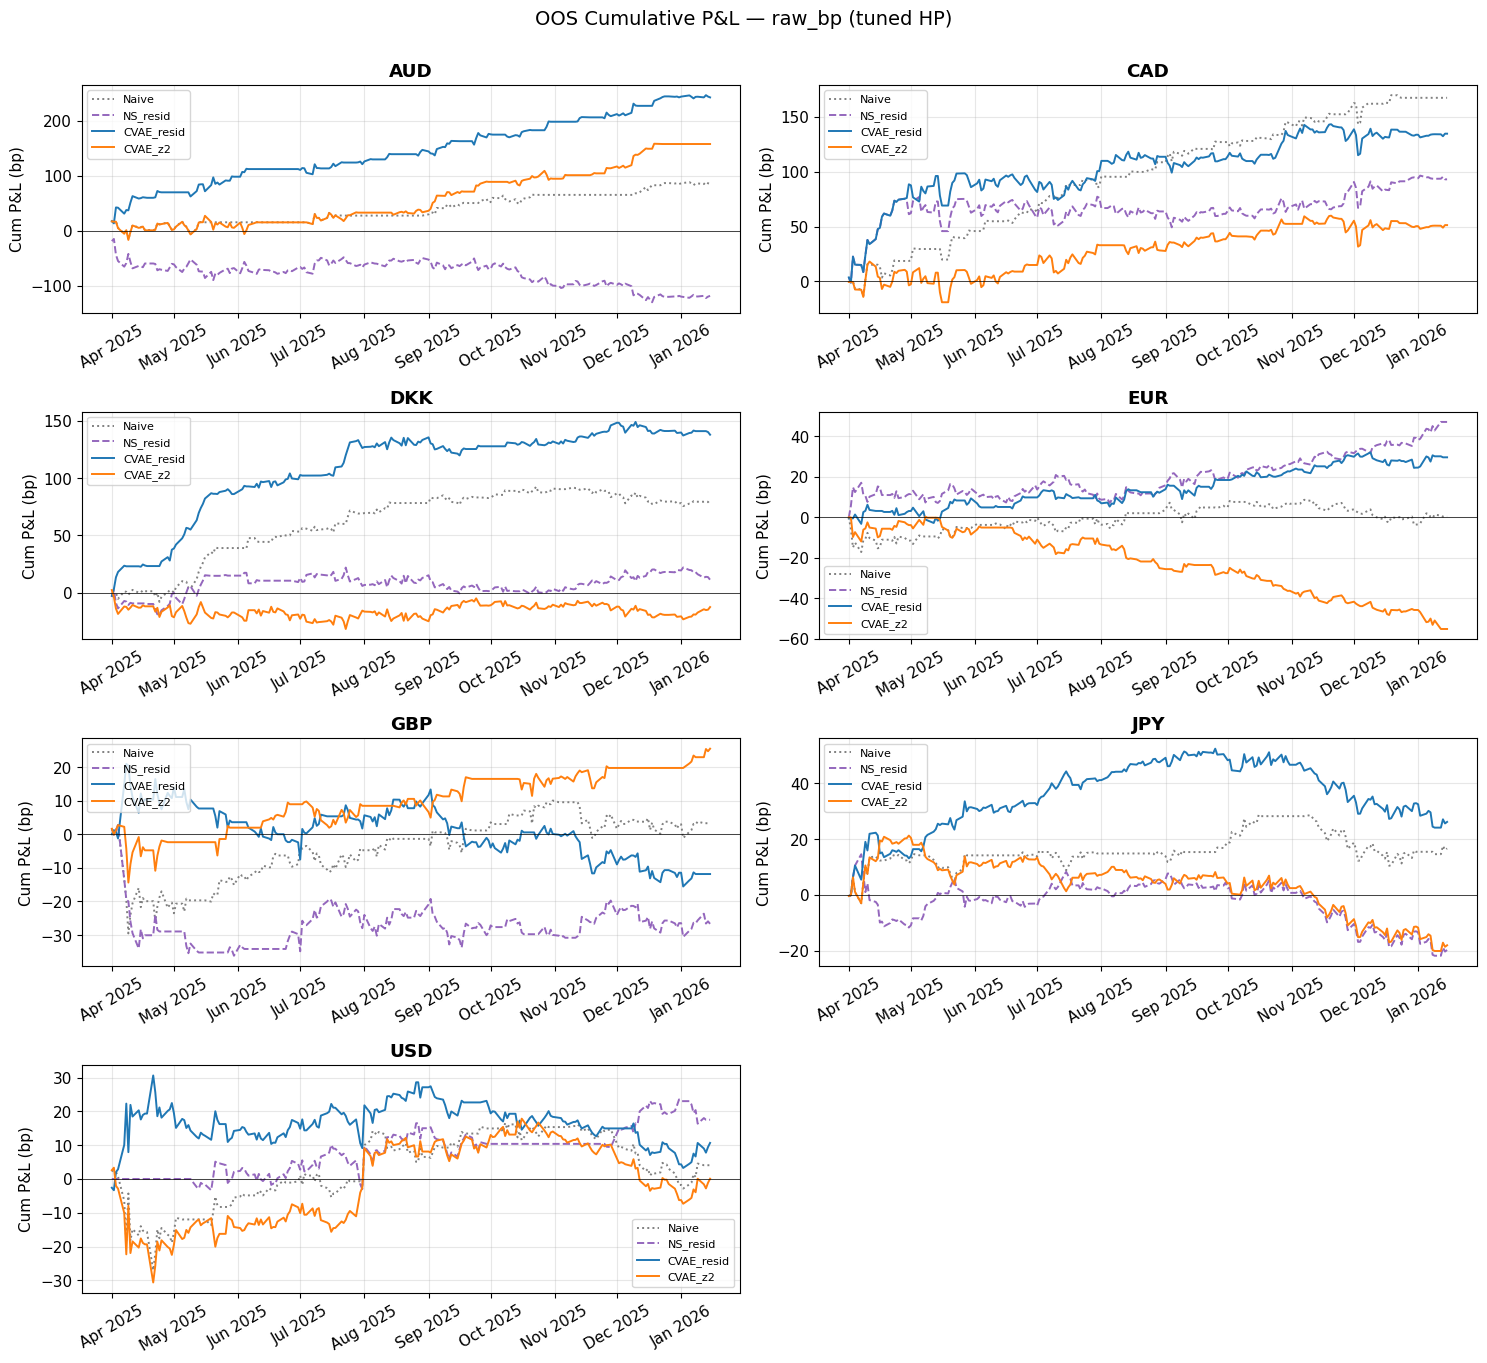

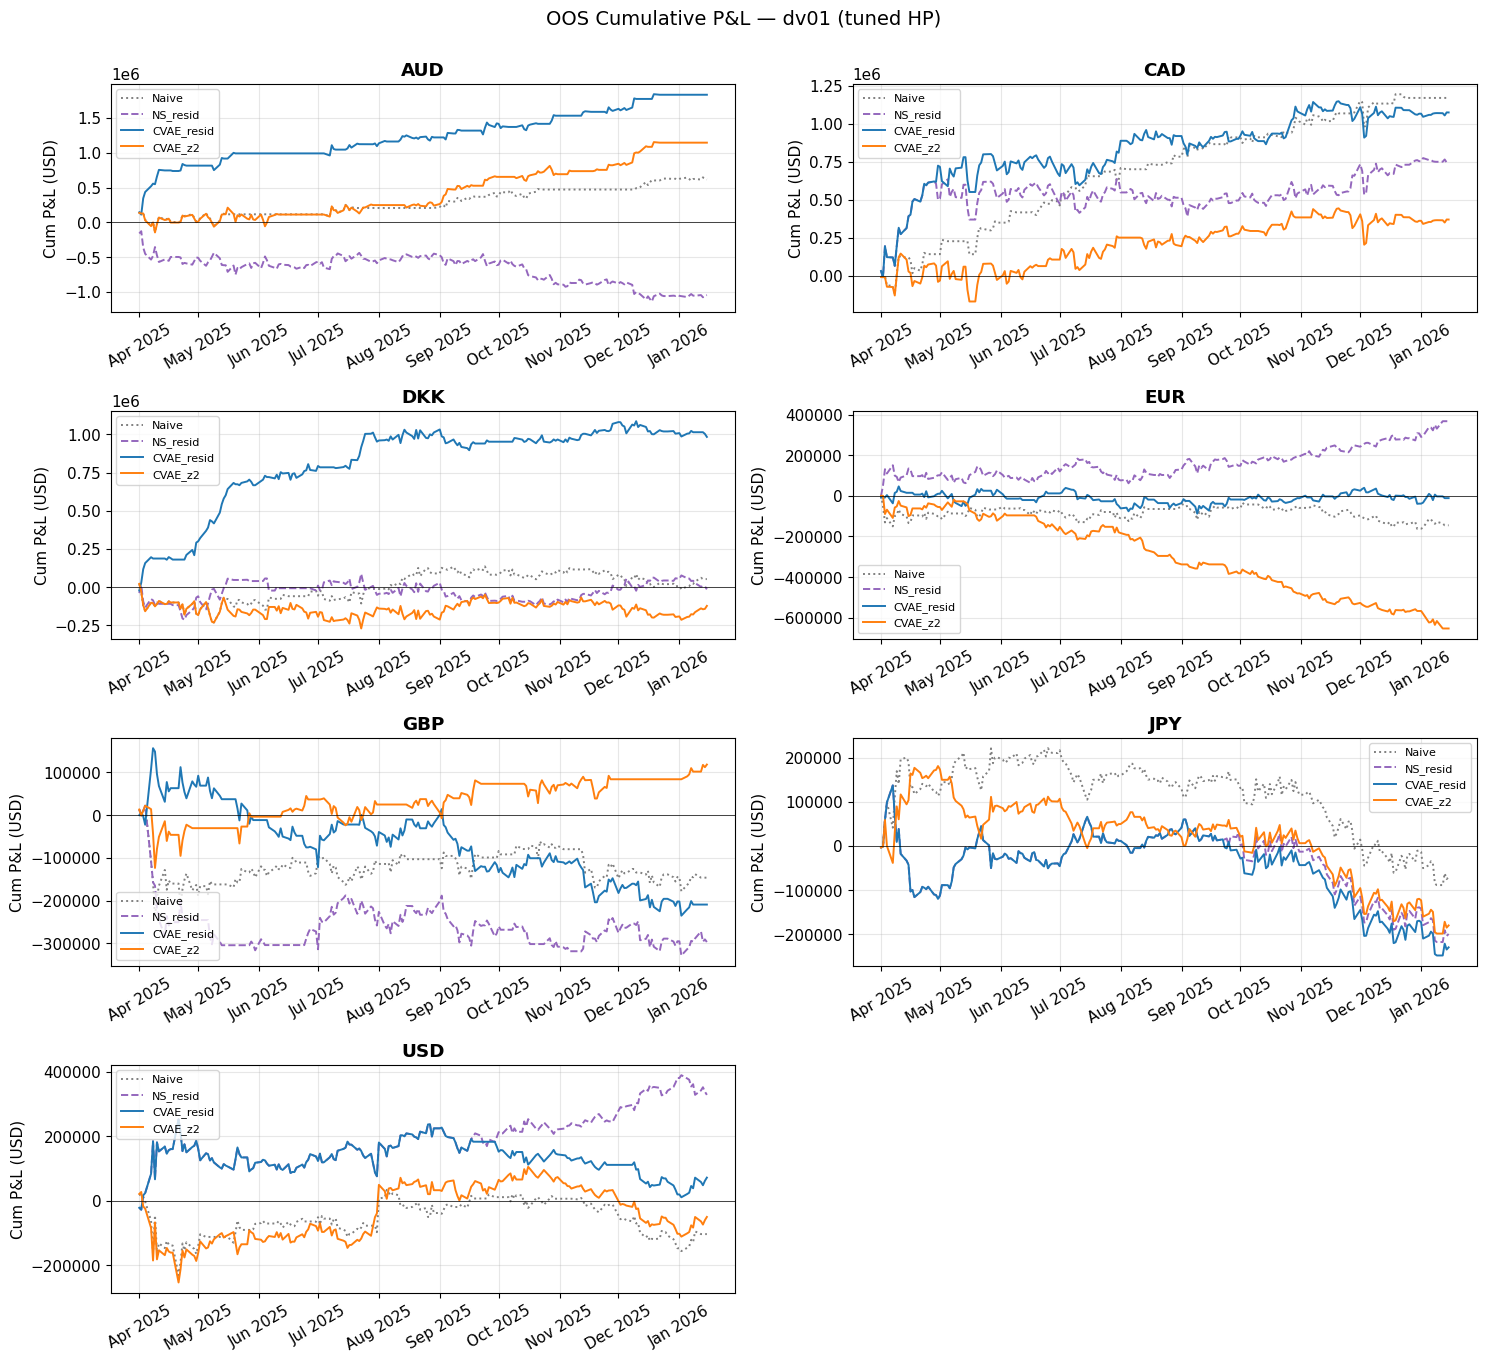

In [30]:
plot_cum_pnl(tuned_btstore, "raw_bp", title_suffix=" (tuned HP)")
plot_cum_pnl(tuned_btstore, "dv01",   title_suffix=" (tuned HP)")

In [31]:
# Portfolio with tuned HP
port_rows_opt = []
for sig_name in SIGNAL_LIBRARY:
    for pnl_mode in ("raw_bp", "dv01"):
        pnl = portfolio_pnl(tuned_btstore, sig_name, pnl_mode)
        s = perf_stats(pnl, label=f"PORT|{sig_name}|{pnl_mode}")
        s.update(signal=sig_name, pnl_mode=pnl_mode, regime="optimised")
        port_rows_opt.append(s)
df_port_opt = pd.DataFrame(port_rows_opt)

print("Equal-weight portfolio (TUNED HP) — RAW BP")
print(df_port_opt[df_port_opt["pnl_mode"] == "raw_bp"]
      .set_index("signal")[["Total", "Ann", "Vol", "Sharpe", "MaxDD", "HitRate"]]
      .round(2))
print()
print("Equal-weight portfolio (TUNED HP) — DV01")
print(df_port_opt[df_port_opt["pnl_mode"] == "dv01"]
      .set_index("signal")[["Total", "Ann", "Vol", "Sharpe", "MaxDD", "HitRate"]]
      .round(2))

Equal-weight portfolio (TUNED HP) — RAW BP
            Total    Ann    Vol  Sharpe  MaxDD  HitRate
signal                                                 
CVAE_resid  81.36  98.57  24.69    3.99  -6.45     0.55
NS_resid     0.68   0.82  20.39    0.04  -9.87     0.50
Naive       50.52  61.21  19.31    3.17 -11.08     0.57
CVAE_z2     21.31  25.82  24.63    1.05 -10.92     0.49

Equal-weight portfolio (TUNED HP) — DV01
                Total        Ann        Vol  Sharpe      MaxDD  HitRate
signal                                                                 
CVAE_resid  501825.71  607981.15  207799.01    2.93  -55748.77     0.51
NS_resid    -16282.02  -19726.29  168149.69   -0.12  -90987.62     0.50
Naive       196240.77  237753.24  170800.24    1.39 -103456.06     0.48
CVAE_z2      89691.21  108664.35  208318.72    0.52  -95745.73     0.47


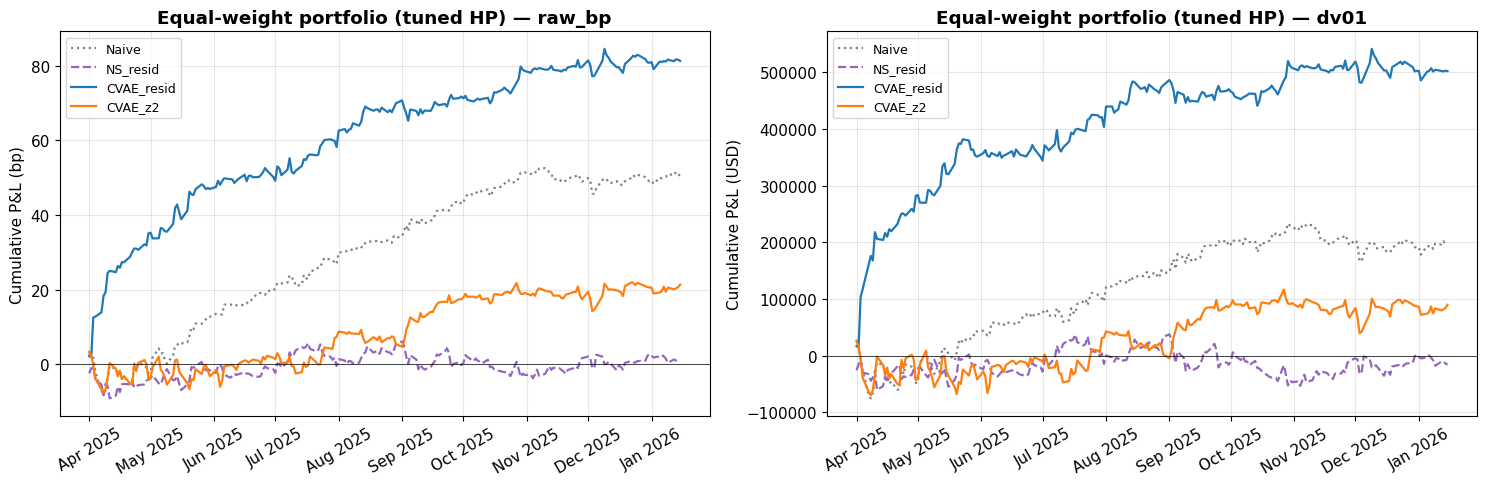

In [32]:
# Visualise the optimised portfolio
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {"Naive": "gray", "NS_resid": "tab:purple",
          "CVAE_resid": "tab:blue", "CVAE_z2": "tab:orange"}
styles = {"Naive": ":", "NS_resid": "--", "CVAE_resid": "-", "CVAE_z2": "-"}

for ax, mode in zip(axes, ["raw_bp", "dv01"]):
    for sig in ["Naive", "NS_resid", "CVAE_resid", "CVAE_z2"]:
        pnl = portfolio_pnl(tuned_btstore, sig, mode)
        if len(pnl):
            ax.plot(pnl.index, pnl.cumsum(), label=sig, color=colors[sig],
                    linestyle=styles[sig], lw=1.6)
    ax.axhline(0, color="black", lw=0.5)
    unit = "bp" if mode == "raw_bp" else "USD"
    ax.set_title(f"Equal-weight portfolio (tuned HP) — {mode}", fontweight="bold")
    ax.set_ylabel(f"Cumulative P&L ({unit})")
    ax.legend(loc="best", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_21_portfolio_opt.png", dpi=140, bbox_inches="tight")
plt.show()

## 14 — Fixed vs optimised regime: did tuning help?

In [33]:
def regime_compare(df_fixed_, df_opt_, pnl_mode):
    f = (df_fixed_[df_fixed_["pnl_mode"] == pnl_mode]
         .groupby("signal")["Sharpe"].mean().rename("Fixed"))
    o = (df_opt_[df_opt_["pnl_mode"] == pnl_mode]
         .groupby("signal")["Sharpe"].mean().rename("Optimised"))
    out = pd.concat([f, o], axis=1).round(2)
    out["Δ"] = (out["Optimised"] - out["Fixed"]).round(2)
    return out

print("Avg OOS Sharpe across currencies — RAW BP")
print(regime_compare(df_fixed, df_opt, "raw_bp"))
print()
print("Avg OOS Sharpe across currencies — DV01")
print(regime_compare(df_fixed, df_opt, "dv01"))

Avg OOS Sharpe across currencies — RAW BP
            Fixed  Optimised     Δ
signal                            
CVAE_resid   1.69       1.66 -0.03
CVAE_z2      0.27       0.12 -0.15
NS_resid    -0.04       0.16  0.20
Naive        0.68       1.18  0.50

Avg OOS Sharpe across currencies — DV01
            Fixed  Optimised     Δ
signal                            
CVAE_resid   1.24       1.02 -0.22
CVAE_z2      0.05      -0.14 -0.19
NS_resid    -0.55       0.04  0.59
Naive        0.42       0.34 -0.08


## 15 — Save trading results

In [34]:
trading_output = {
    "panels":          panels,
    "df_fixed":        df_fixed,
    "df_opt":          df_opt,
    "df_port_fixed":   df_port_fixed,
    "df_port_opt":     df_port_opt,
    "tuned_hp":        tuned_hp,
    "config": {
        "currencies":   CURRENCIES,
        "tenors":       TARGET_TENORS,
        "train_cutoff": str(TRAIN_CUTOFF),
        "hp_fixed":     HP_FIXED,
        "entry_grid":   ENTRY_GRID,
        "exit_grid":    EXIT_GRID,
        "lookback_grid": LOOKBACK_GRID,
        "tc_bp":        TC_FIXED,
    },
}
with open(RES_DIR / "trading_results.pkl", "wb") as f:
    pickle.dump(trading_output, f)
print("✓ Saved results/trading_results.pkl")

✓ Saved results/trading_results.pkl


## 16 — Honest reporting & caveats

**Sample size warning.**
With ~3 years of data and a 70/30 split, the OOS window is roughly 230
business days (~9 months). All Sharpe ratios reported above are computed on
this short window. With this much data, the standard error on an annualised
Sharpe is approximately $\sqrt{1/n_{years}} \approx 1.1$, so any reported
Sharpe within ±1 of zero is statistically indistinguishable from noise. The
purpose of this notebook is to **demonstrate the methodology**, not to claim a
genuine alpha.

**What is genuinely informative here.**
- The *relative* ranking of signals (Naive vs NS vs CVAE) is more meaningful
  than any absolute number, because all three see the exact same OOS window.
- The comparison of *fixed* vs *optimised* HP gives an estimate of how much
  the strategy is at risk of overfitting on a longer sample.
- The DV01-weighted vs raw-bp comparison shows whether the simple bp P&L
  dramatically over- or under-states the realistic dollar P&L.

**What would make this credible at a desk.**
- A 10–20-year sample (the original Sokol paper uses 22 years).
- Walk-forward optimisation with rolling re-fits of the CVAE.
- Carry / roll-down accounting (LOIM 2022 stresses that 2s10s flatteners have
  *negative* carry, which can dominate short-window P&L).
- Realistic transaction costs that vary with trade size and market regime.
- A funding-rate adjustment to convert bp P&L into a risk-free-relative return
  (CME Group, *Yield Curve Spread Trades*).

**References used in the construction**
- DV01 weighting of swap spreads: Clarus FT, *Mechanics and Definitions of
  Spread and Butterfly Swap Packages* (2014).
- Annuity DV01 approximation: CME Group, *Swap Rate Curve Strategies with
  Deliverable Interest Rate Swap Futures*.
- 2s10s flattener in hiking cycles, with carry caveat: Lombard Odier IM,
  *Exploiting yield-curve dynamics in hiking cycles* (2022).
- Conventional 50/50 vs cash & DV01-neutral butterfly weights: Montréal
  Exchange, *Understanding 2-5-10 Butterfly Trades in Futures* (2021).
- Return estimation via DV01 × spread change: CME Group, *Yield Curve Spread
  Trades: Opportunities & Applications*.


# Extensions


Sections added:
- **A — DV01 sign fix**: corrects the leg-orientation bug in `backtest(..., pnl_mode="dv01")`
- **B — Cross-currency convergence in latent space** (Diebold-Li-Yue, Sokol §3.3)
- **C — PCA-on-latent residual trading** (Litterman-Scheinkman, Kondratyev 2018)
- **D — Carry-aware P&L** (Lombard Odier 2022)
- **E — 2s5s10s butterfly with CVAE fair value** (Sokol §4.3)


## B — Cross-currency convergence in latent space

### Idea
The **multi-currency VAE** (the non-conditional one from NB3) maps every
currency curve into the **same** 2-D latent space `(z₁, z₂)`. Two currencies
whose curves are close in this latent space have "structurally equivalent
shapes" — same level/slope regime.

When two currencies that are normally close in latent space drift apart, this
is a relative-value signal: their curves should converge back. We trade the
**spread of slopes** between the two currencies:
- if ccy_A's slope is too steep relative to ccy_B → flatten A, steepen B
- and vice-versa

This is the natural extension of Diebold-Li-Yue (2008) "Global yield curve
dynamics and interactions" who do the same thing with Nelson-Siegel factors,
and the empirical realisation of Sokol (2022) §3.3 which only sketches the
idea.

### Technical implementation
1. Encode every currency's curves with the **multi-VAE** (`vae_data["multi_vae_state"]`)
2. For every currency pair `(A, B)`, compute the per-day latent distance
   `d_t = ||z^A_t − z^B_t||₂`
3. Z-score `d_t` over a rolling window
4. When `d_t` is unusually large → trade convergence:
   `pos_A = -pos_B`, both being slope mean-reversion bets

For the actual P&L, we trade the **slope spread** `(slope_A − slope_B)`. The
position sign is `−sign(slope_spread − rolling_mean)` so that we fade the
deviation.

### Why it's ONLY possible with the multi-VAE
Nelson-Siegel fits each currency independently, so its factors live in
**different** spaces — you can't directly compare an NS slope from USD to one
from EUR. The multi-VAE forces all currencies through the same encoder, so its
latent space is by construction comparable across currencies.


In [35]:
# ── Reload the multi-VAE (non-conditional) from NB3 ─────────────
class MultiVAE(nn.Module):
    """Same architecture as the multi-currency VAE in NB3 (Table 2 of Sokol)."""
    def __init__(self, input_dim=7, latent_dim=2, hidden_dim=4):
        super().__init__()
        self.input_dim, self.latent_dim = input_dim, latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim), nn.Tanh(),
            nn.Linear(input_dim, 2 * latent_dim))
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, input_dim), nn.Tanh(),
            nn.Linear(input_dim, input_dim), nn.Sigmoid())
    def encode(self, x):
        h = self.encoder(x)
        return h[:, :self.latent_dim], h[:, self.latent_dim:]
    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decoder(mu), mu, logvar

multi_vae = MultiVAE(input_dim=len(TARGET_TENORS), latent_dim=2, hidden_dim=4).to(device)
multi_vae.load_state_dict(vae_data["multi_vae_state"])
multi_vae.eval()

# ── Encode every currency in the SHARED latent space ─────────────
# IMPORTANT: this is the MULTI-VAE, not the CVAE. Cross-currency comparison
# is only meaningful here because all currencies share the same encoder.
latent_shared: dict[str, pd.DataFrame] = {}
for ccy in CURRENCIES:
    df = swap_aligned[ccy]
    X = torch.from_numpy(normalize_rates(df.values).astype(np.float32)).to(device)
    with torch.no_grad():
        _, mu, _ = multi_vae(X)
    latent_shared[ccy] = pd.DataFrame(mu.cpu().numpy(),
                                      index=df.index, columns=["z1", "z2"])

print(f"Encoded {len(latent_shared)} currencies in the shared latent space")
latent_shared[CURRENCIES[0]].tail(3)

Encoded 7 currencies in the shared latent space


,z1,z2
Date,,
2026-01-13,0.300777,1.914474
2026-01-14,0.296967,1.908791
2026-01-15,0.292042,1.912517


Trading 21 currency pairs


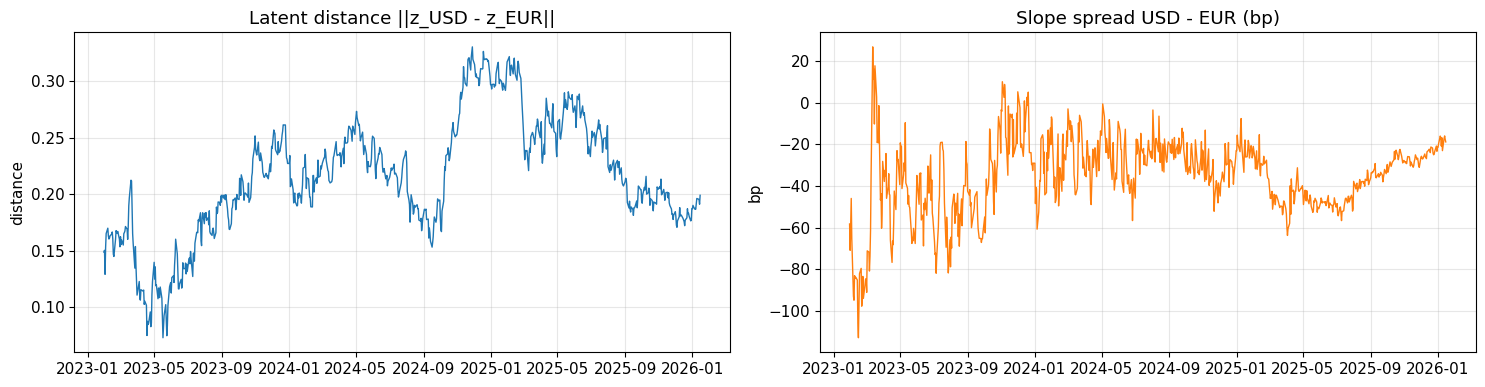

In [36]:
# ── Build all currency pairs and the latent-distance signal ─────
from itertools import combinations

PAIRS = list(combinations(CURRENCIES, 2))   # 7 ccy → 21 pairs
print(f"Trading {len(PAIRS)} currency pairs")

def latent_distance(ccy_a: str, ccy_b: str) -> pd.Series:
    """Euclidean distance ||z_A - z_B||_2 in the SHARED latent space."""
    za = latent_shared[ccy_a]
    zb = latent_shared[ccy_b]
    common = za.index.intersection(zb.index)
    diff = za.loc[common] - zb.loc[common]
    return np.sqrt((diff ** 2).sum(axis=1))

def slope_spread(ccy_a: str, ccy_b: str) -> pd.Series:
    """slope_A - slope_B in bp."""
    sa = panels[ccy_a]["slope_bp"]
    sb = panels[ccy_b]["slope_bp"]
    common = sa.index.intersection(sb.index)
    return sa.loc[common] - sb.loc[common]

# Quick visualisation: distance for one example pair
ccy_a, ccy_b = "USD", "EUR"
dist_usd_eur = latent_distance(ccy_a, ccy_b)
spread_usd_eur = slope_spread(ccy_a, ccy_b)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(dist_usd_eur, lw=1, color="tab:blue")
axes[0].set_title(f"Latent distance ||z_{ccy_a} - z_{ccy_b}||")
axes[0].set_ylabel("distance")
axes[1].plot(spread_usd_eur, lw=1, color="tab:orange")
axes[1].set_title(f"Slope spread {ccy_a} - {ccy_b} (bp)")
axes[1].set_ylabel("bp")
plt.tight_layout(); plt.show()

In [37]:
# ── Cross-currency convergence backtest ─────────────────────────
def backtest_pair_convergence(
    ccy_a: str, ccy_b: str,
    entry_z: float = 1.0, exit_z: float = 0.3, lookback: int = 60, tc_bp: float = 1.0,
) -> pd.DataFrame:
    """
    Convergence trade on the slope spread between two currencies.

    Signal:
        z_t = z-score of the SLOPE SPREAD (slope_A - slope_B), 60d rolling
        (we use slope spread directly rather than latent distance because the
         latent distance is sign-less; the slope spread has a sign and tells
         us which currency to flatten and which to steepen.)

    Position (from build_positions, which already flips the sign of z):
        -1 when z > +entry_z  (spread too high → flatten A, steepen B)
        +1 when z < -entry_z  (spread too low  → steepen A, flatten B)

    P&L (raw bp): pos_lag * Δ(slope_A - slope_B)
        Because `pos` already encodes the convergence bet (pos = -sign(z)
        for large |z|), multiplying directly by Δspread yields positive P&L
        on reversion — no extra sign flip needed.

    TC: 1 bp per direction flip (twice 0.5 bp because 4 legs total, 2 swaps per ccy)
    """
    spread = slope_spread(ccy_a, ccy_b)
    spread_chg = spread.diff()
    z = compute_zscore(spread, lookback)
    pos = build_positions(z, entry_z, exit_z)   # +1 / -1 / 0
    pos_lag = pos.shift(1).fillna(0.0)

    # Convergence: pos = -1 when spread is high; if spread reverts down,
    # spread_chg < 0 and pnl = (-1)(-) = +.
    pnl = pos_lag * spread_chg
    tc = pos_lag.diff().abs().fillna(0.0) * tc_bp
    net = pnl - tc

    return pd.DataFrame({
        "spread_bp": spread,
        "zscore":    z,
        "position":  pos,
        "pnl":       net,
        "cum_pnl":   net.cumsum(),
    })

# Run for every pair, OOS only
pair_results = {}
rows = []
for a, b in PAIRS:
    bt = backtest_pair_convergence(a, b)
    bt_oos = bt.loc[bt.index > TRAIN_CUTOFF]
    pair_results[(a, b)] = bt
    s = perf_stats(bt_oos["pnl"], label=f"{a}-{b}")
    s["pair"] = f"{a}-{b}"
    rows.append(s)

df_pairs = pd.DataFrame(rows).set_index("pair").sort_values("Sharpe", ascending=False)
print("Cross-currency convergence — top 10 pairs by OOS Sharpe (raw bp)")
print(df_pairs[["Sharpe", "Total", "MaxDD", "HitRate", "NumTrades"]].head(10).round(2))
print(f"\nMean Sharpe across {len(PAIRS)} pairs: {df_pairs['Sharpe'].mean():.2f}")
print(f"Pairs with Sharpe > 1: {(df_pairs['Sharpe'] > 1).sum()} / {len(df_pairs)}")

Cross-currency convergence — top 10 pairs by OOS Sharpe (raw bp)
         Sharpe   Total  MaxDD  HitRate  NumTrades
pair                                              
CAD-USD    3.45  186.42 -15.39     0.50        113
CAD-GBP    3.44  236.18 -25.95     0.51        139
AUD-EUR    3.16  189.30 -30.31     0.53        122
CAD-DKK    3.13  180.36 -22.06     0.53        148
AUD-GBP    3.13  219.27 -26.38     0.55        130
DKK-GBP    2.99  121.21  -9.16     0.48        134
CAD-JPY    2.78  159.25 -19.30     0.54        128
AUD-DKK    2.53  152.81 -24.37     0.55        130
CAD-EUR    2.50  123.87 -23.45     0.55        132
DKK-EUR    2.05   71.30 -14.83     0.50        117

Mean Sharpe across 21 pairs: 1.87
Pairs with Sharpe > 1: 16 / 21


Equal-weight cross-currency portfolio (OOS)
  label    N       Total         Ann        Vol    Sharpe     MaxDD  HitRate  \
0  PORT  208  105.059929  127.284144  27.837333  4.572426 -5.596524  0.57971   

  NumTrades  
0       207  


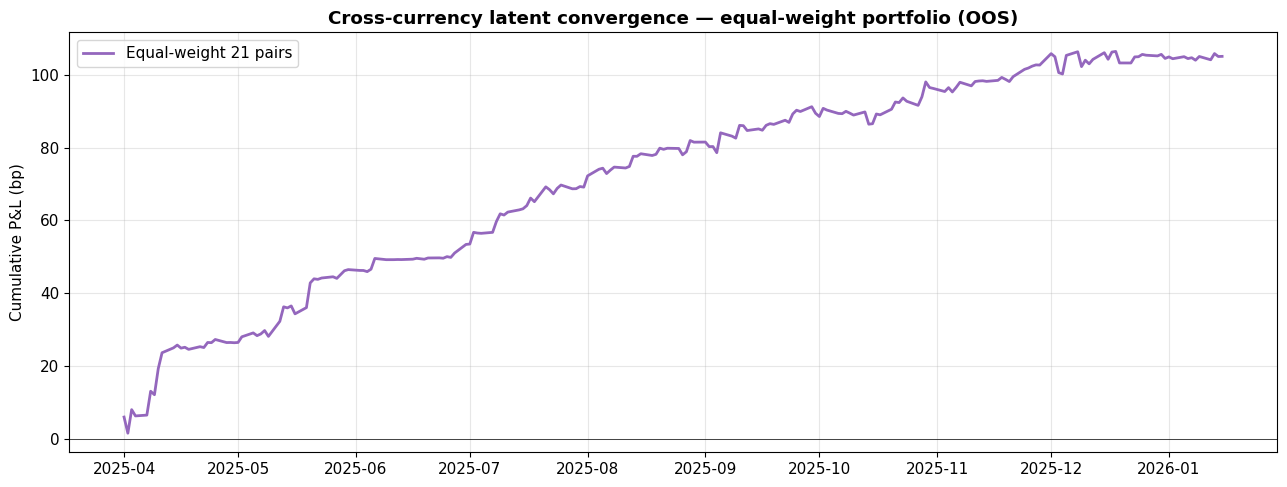

In [38]:
# ── Equal-weight portfolio across all 21 pairs ──────────────────
pair_pnl = pd.concat(
    [pair_results[p].loc[pair_results[p].index > TRAIN_CUTOFF, "pnl"].rename(f"{p[0]}-{p[1]}")
     for p in PAIRS],
    axis=1,
).fillna(0.0)

port_pair_pnl = pair_pnl.mean(axis=1)
print("Equal-weight cross-currency portfolio (OOS)")
print(pd.Series(perf_stats(port_pair_pnl, "PORT")).to_frame().T.round(2))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(port_pair_pnl.cumsum(), lw=2, color="tab:purple", label="Equal-weight 21 pairs")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Cross-currency latent convergence — equal-weight portfolio (OOS)",
             fontweight="bold")
ax.set_ylabel("Cumulative P&L (bp)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_22_xccy_convergence.png", dpi=140, bbox_inches="tight")
plt.show()

## C — PCA-on-latent residual trading

### Idea
The CVAE encodes a 7-dim curve into a 2-dim latent. The decoder is non-linear,
so the relationship between `dz` and `dr_t` (rate change at tenor t) is too,
but **locally** we can linearise with a regression:

$$\Delta r_{t,T} \approx \alpha_T + \beta_{T,1}\Delta z_{1,t} + \beta_{T,2}\Delta z_{2,t} + \epsilon_{t,T}$$

The residual `ε_{t,T}` is the part of the move at tenor T that **cannot be
explained** by the latent factors. Following Litterman-Scheinkman (1991, the
PCA original) and Kondratyev (2018) on neural curve models, we treat `ε` as
**idiosyncratic mispricing** at that tenor and trade its mean-reversion.

### Mechanics
1. Compute `dz₁, dz₂` (CVAE latent changes) and `dr_T` (rate changes) per ccy
2. Fit OLS for each tenor T → residuals `ε_{t,T}`
3. Z-score the residuals (rolling)
4. When `|z| > 1.0`, fade the residual: long the tenor if its move was too
   negative (residual < 0), short if too positive
5. P&L is the directional bet on a single tenor, in DV01-weighted dollars

### Why this differs from Strategy A
Strategy A (CVAE_resid) trades the *slope-level* residual. This strategy
trades the *per-tenor* residual after explicitly removing the latent factor
loadings. It's strictly more granular and isolates idiosyncratic shocks.


In [39]:
def pca_latent_residuals(ccy: str, train_cutoff: pd.Timestamp) -> pd.DataFrame:
    """
    Fit OLS dr_T = a_T + b_T1·dz1 + b_T2·dz2 + eps  on the TRAIN window only.
    Apply to the full sample to get residuals everywhere (OOS-safe).
    """
    df = swap_aligned[ccy]
    p  = panels[ccy]   # already has z2 column from CVAE
    # We need both z1 and z2 here. CVAE gives both. Re-encode to grab z1 too.
    rates_norm = normalize_rates(df.values).astype(np.float32)
    X = torch.from_numpy(rates_norm).to(device)
    oh = np.zeros((len(df), N_CCY), dtype=np.float32)
    oh[:, CCY_TO_IDX[ccy]] = 1.0
    Y = torch.from_numpy(oh).to(device)
    with torch.no_grad():
        _, mu, _ = cvae(X, Y)
    z = pd.DataFrame(mu.cpu().numpy(), index=df.index, columns=["z1", "z2"])

    dz = z.diff()
    dr = df.diff()    # change in rates per tenor (decimal)

    train_mask = dr.index <= train_cutoff
    eps_all = pd.DataFrame(index=dr.index, columns=TARGET_TENORS, dtype=float)
    coefs = {}
    for T in TARGET_TENORS:
        # OLS on train window only (no look-ahead)
        X_train = np.column_stack([
            np.ones(train_mask.sum()),
            dz.loc[train_mask, "z1"].fillna(0).values,
            dz.loc[train_mask, "z2"].fillna(0).values,
        ])
        y_train = dr.loc[train_mask, T].fillna(0).values
        beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
        coefs[T] = beta
        # Apply to full sample
        X_full = np.column_stack([
            np.ones(len(dr)),
            dz["z1"].fillna(0).values,
            dz["z2"].fillna(0).values,
        ])
        y_pred = X_full @ beta
        eps_all[T] = dr[T].values - y_pred

    # Convert residuals to bp for readability
    return eps_all * BP_PER_UNIT, pd.DataFrame(coefs, index=["alpha", "b_z1", "b_z2"]).T

# Demo on USD
eps_usd, coefs_usd = pca_latent_residuals("USD", TRAIN_CUTOFF)
print("OLS coefficients for USD (per tenor): dr_T ≈ a + b1·dz1 + b2·dz2")
print(coefs_usd.round(6))
print(f"\nResidual std (bp) per tenor: {eps_usd.std().round(2).to_dict()}")

OLS coefficients for USD (per tenor): dr_T ≈ a + b1·dz1 + b2·dz2
       alpha      b_z1      b_z2
2  -0.000002 -0.029201 -0.014558
3   0.000001 -0.032634 -0.006974
5   0.000004 -0.029481 -0.003613
10 -0.000007 -0.024591  0.016957
15  0.000004 -0.015238  0.006038
20 -0.000002 -0.019705  0.018044
30  0.000000 -0.018791  0.017306

Residual std (bp) per tenor: {2: 4.61, 3: 4.89, 5: 4.83, 10: 3.28, 15: 4.72, 20: 2.31, 30: 2.23}


In [ ]:
# ── Backtest the per-tenor residual mean-reversion ──────────────
def backtest_tenor_residual(
    ccy: str, tenor: int,
    entry_z: float = 1.0, exit_z: float = 0.3, lookback: int = 60, tc_bp: float = 0.5,
) -> pd.DataFrame:
    """
    Mean-reversion on the per-tenor residual eps_{t,T} from the latent regression.

    Signal: z-score of cumulative residuals (the residual is a daily change, so
            we cumsum to get a "level" on which mean-reversion makes sense).

    Position (from build_positions, which gives pos = -sign(z) for |z|>entry):
        -1 when z > +entry_z : cum_eps too high → expect reversion down →
                               future dr_T < latent prediction; under the
                               (average) assumption dz ≈ 0 this implies dr < 0,
                               so the desired trade is LONG the tenor
                               (receive fixed), profiting when r_T falls.
        +1 when z < -entry_z : symmetric — SHORT the tenor (pay fixed).

    P&L (bp):  pnl = pos_lag * dr_T_bp
        With the build_positions sign convention, pos = -1 should profit when
        r_T falls (dr_T < 0): (-1)(negative) = positive ✓. The older formula
        `pnl = -pos * dr` had an extra sign flip and traded the wrong way.
    """
    eps_bp, _ = pca_latent_residuals(ccy, TRAIN_CUTOFF)
    cum_eps = eps_bp[tenor].cumsum()

    z = compute_zscore(cum_eps, lookback)
    pos = build_positions(z, entry_z, exit_z)
    pos_lag = pos.shift(1).fillna(0.0)

    dr_T_bp = swap_aligned[ccy][tenor].diff() * BP_PER_UNIT
    # pos = -1 (cum_eps high, expect r_T to fall) * (dr < 0) → positive P&L
    pnl = pos_lag * dr_T_bp
    tc  = pos_lag.diff().abs().fillna(0.0) * tc_bp
    net = pnl - tc
    return pd.DataFrame({
        "cum_eps":  cum_eps,
        "zscore":   z,
        "position": pos,
        "pnl":      net,
        "cum_pnl":  net.cumsum(),
    }, index=swap_aligned[ccy].index)

# Run on the 7 tenors × 7 currencies
rows = []
for ccy in CURRENCIES:
    for T in TARGET_TENORS:
        bt = backtest_tenor_residual(ccy, T)
        oos = bt.loc[bt.index > TRAIN_CUTOFF, "pnl"]
        s = perf_stats(oos)
        s.update(currency=ccy, tenor=T)
        rows.append(s)
df_tenor = pd.DataFrame(rows)
pivot = df_tenor.pivot_table(index="currency", columns="tenor", values="Sharpe").round(2)
print("Per-tenor residual mean-reversion — OOS Sharpe by (currency, tenor)")
print(pivot)
print(f"\nMean Sharpe: {df_tenor['Sharpe'].mean():.2f}")
print(f"Best tenor: {df_tenor.groupby('tenor')['Sharpe'].mean().idxmax()} "
      f"(avg Sharpe {df_tenor.groupby('tenor')['Sharpe'].mean().max():.2f})")


## D — Carry-aware P&L

### Idea
A 2s10s spread trade has a non-zero **carry** (the daily P&L you get just by
holding the position, even if rates don't move). For a steepener (long 10Y,
short 2Y in DV01-weighted bond terms = pay 10Y fix, receive 2Y fix in swap
terms), the daily carry is approximately:

$$\text{carry}_t = \text{pos} \cdot \frac{r_{2Y,t} - r_{10Y,t}}{252}$$

In a normal upward-sloping curve `r_10Y > r_2Y` so the steepener has
**negative** carry (you receive a low rate and pay a high rate). In an
inverted curve (like much of 2023-2024), the steepener has **positive** carry.

Lombard Odier (2022) flag this as the dominant return component for
2s10s strategies on horizons under 1 year.

### Implementation
We just add `pos × daily_carry_bp` to the existing raw_bp P&L. No change to
the position logic — only the P&L accounting changes.


In [ ]:
def add_carry_to_backtest(
    panel: pd.DataFrame, bt: pd.DataFrame,
) -> pd.DataFrame:
    """
    Augment a raw_bp backtest with daily carry on the 2s10s spread.

    Interpretation of the 'bp' unit. In raw_bp mode, 1 unit of position
    represents a unit-DV01 2s10s spread: i.e. a notional size such that a 1bp
    widening of (10Y - 2Y) yields 1bp of P&L. Under that normalisation, the
    daily coupon accrual of a steepener (+1 = receive 2Y fixed, pay 10Y fixed)
    per unit-DV01 is

        carry_bp = (r_2Y - r_10Y) * BP_PER_UNIT / 252

    in bp/day, consistent with slope_chg_bp already being bp/day. On an
    upward-sloping curve r_10Y > r_2Y, so the steepener carries negatively
    (LOIM 2022); on an inverted curve it carries positively.
    """
    daily_carry_bp = (panel["rate_2Y"] - panel["rate_10Y"]) * BP_PER_UNIT / 252
    pos_lag = bt["position"].shift(1).fillna(0.0)
    carry_pnl = pos_lag * daily_carry_bp

    bt_out = bt.copy()
    bt_out["carry_bp"]    = carry_pnl
    bt_out["pnl_no_carry"]= bt_out["pnl"]
    bt_out["pnl"]         = bt_out["pnl"] + carry_pnl   # overwrite
    bt_out["cum_pnl"]     = bt_out["pnl"].cumsum()
    return bt_out

# Apply to the CVAE_resid strategy and compare
print("Effect of carry on CVAE_resid strategy (OOS, raw bp)")
print("-" * 64)
print(f"{'Currency':<10}{'Sharpe (no carry)':>18}{'Sharpe (+ carry)':>18}{'Avg carry/yr':>18}")
print("-" * 64)
for ccy in CURRENCIES:
    bt_orig = bt_fixed[(ccy, "CVAE_resid", "raw_bp")]
    bt_carr = add_carry_to_backtest(panels[ccy], bt_orig)
    oos = lambda b: b.loc[b.index > TRAIN_CUTOFF, "pnl"]
    s_no = perf_stats(oos(bt_orig))["Sharpe"]
    s_yes = perf_stats(oos(bt_carr))["Sharpe"]
    ann_carry = bt_carr.loc[bt_carr.index > TRAIN_CUTOFF, "carry_bp"].sum() * (252 / 208)
    print(f"{ccy:<10}{s_no:>18.2f}{s_yes:>18.2f}{ann_carry:>16.1f} bp")


## E — 2s5s10s butterfly with CVAE fair value

### Idea
A 2s5s10s butterfly is a 3-leg curve trade: `+2Y +10Y -2×5Y` (or the inverse).
It captures **curvature** — the part of the curve shape that level + slope
miss. The trade is by construction insensitive to parallel shifts (level) and
to slope changes when DV01-weighted.

The CVAE has a **second** latent dimension `z₂` which is theoretically the
curvature factor (Sokol §4.3). So we can build a fair-value butterfly:

$$\text{butterfly}_t = 2 \cdot r_{5Y,t} - r_{2Y,t} - r_{10Y,t}$$

and trade `actual_butterfly − cvae_butterfly` mean-reversion, exactly like
Strategy A but on the fly instead of the slope.

### Why it should work better in principle
Bikbov & Chernov (2010) show that on swap curves, the curvature factor is the
**most predictable** of the three (PCA factors level/slope/curvature). It also
has the lowest carry (the wings cancel out partly), so the carry drag we just
saw on the slope is much smaller here.


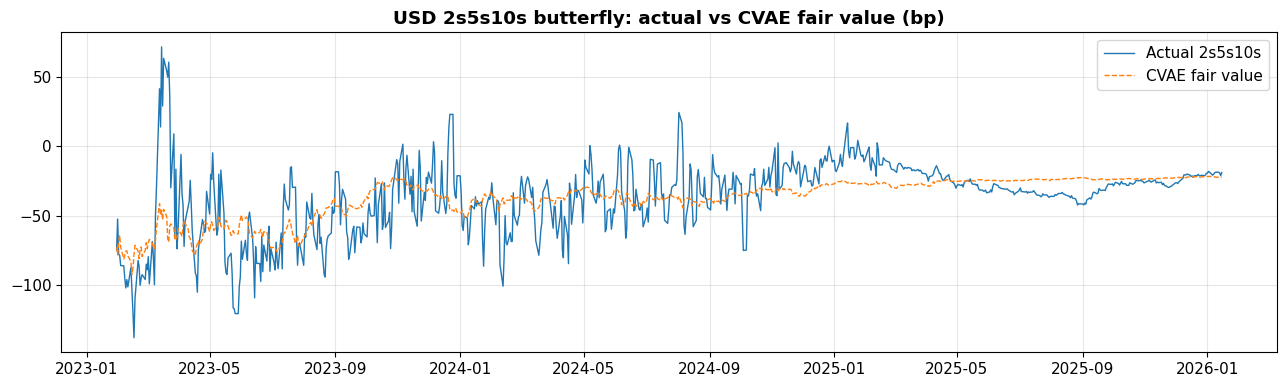

In [42]:
# ── Compute butterfly panels and CVAE fair-value butterfly ──────
def build_butterfly_panel(ccy: str) -> pd.DataFrame:
    df = swap_aligned[ccy]
    cv = cvae_fair_value(df, ccy)

    # 2s5s10s butterfly = 2*5Y - 2Y - 10Y    (positive when 5Y is rich)
    bf_actual = (2 * df[5] - df[2] - df[10]) * BP_PER_UNIT
    bf_cvae   = (2 * cv[5] - cv[2] - cv[10]) * BP_PER_UNIT

    p = pd.DataFrame(index=df.index)
    p["rate_2Y"]      = df[2]
    p["rate_5Y"]      = df[5]
    p["rate_10Y"]     = df[10]
    p["bf_bp"]        = bf_actual
    p["bf_chg_bp"]    = bf_actual.diff()
    p["cvae_bf_bp"]   = bf_cvae
    p["cvae_bf_resid"]= bf_actual - bf_cvae
    return p

butterfly_panels = {ccy: build_butterfly_panel(ccy) for ccy in CURRENCIES}

# Quick sanity check on USD
bf_usd = butterfly_panels["USD"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(bf_usd["bf_bp"],      lw=1.0, label="Actual 2s5s10s",  color="tab:blue")
ax.plot(bf_usd["cvae_bf_bp"], lw=1.0, label="CVAE fair value", color="tab:orange",
        linestyle="--")
ax.set_title("USD 2s5s10s butterfly: actual vs CVAE fair value (bp)",
             fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

CVAE 2s5s10s butterfly mean-reversion — OOS
          Sharpe   Total  MaxDD  HitRate  NumTrades
currency                                           
AUD         3.09  203.24 -21.50     0.55        104
CAD         2.05  161.54 -31.48     0.57        124
DKK         3.03  116.82 -14.39     0.54        106
EUR         3.99  283.77 -27.97     0.57        111
GBP        -1.60  -19.84 -20.88     0.44        153
JPY         0.63   13.20 -12.80     0.49        146
USD        -1.24  -21.78 -28.31     0.44        188

Equal-weight portfolio Sharpe: 5.12
Equal-weight portfolio total P&L (bp): 105.3


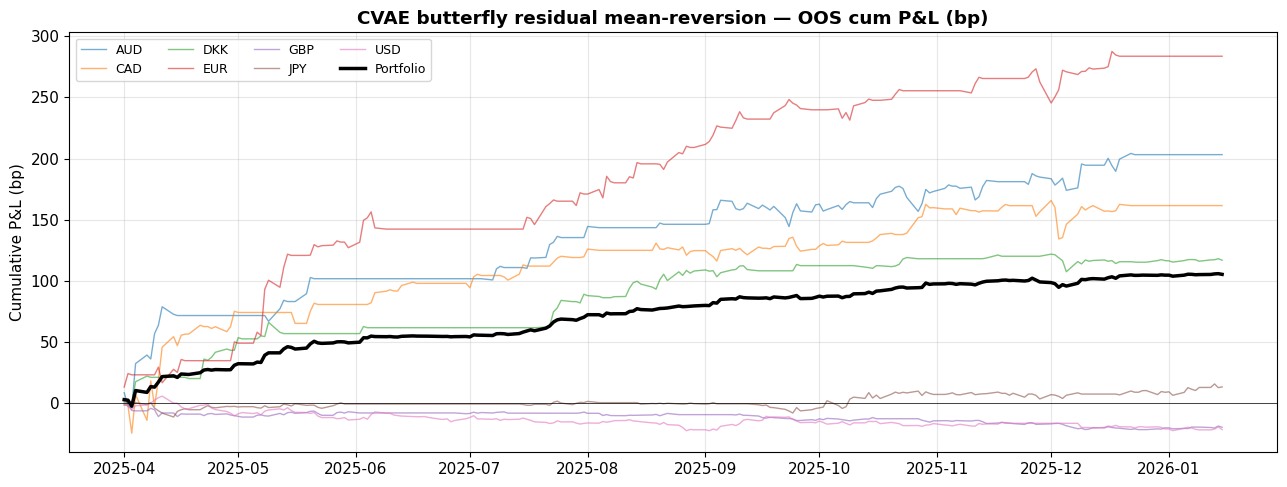

In [43]:
def backtest_butterfly_residual(
    panel: pd.DataFrame,
    entry_z: float = 1.0, exit_z: float = 0.3, lookback: int = 60, tc_bp: float = 1.0,
) -> pd.DataFrame:
    """
    Mean-reversion on the CVAE butterfly residual.

    Signal: residual = actual_bf - cvae_bf, z-scored
    Position:
        +1 = long body / short wings  (bet bf widens upward)
        -1 = short body / long wings  (bet bf narrows)
    P&L (raw bp): pos_lag * Δ(butterfly)  in bp.
                  4 legs total ⇒ tc = 1 bp per direction flip.
    """
    z = compute_zscore(panel["cvae_bf_resid"], lookback)
    pos = build_positions(z, entry_z, exit_z)   # +1 = bet bf increases
    pos_lag = pos.shift(1).fillna(0.0)
    pnl = pos_lag * panel["bf_chg_bp"]
    tc = pos_lag.diff().abs().fillna(0.0) * tc_bp
    net = pnl - tc
    return pd.DataFrame({
        "bf_bp":    panel["bf_bp"],
        "resid_bp": panel["cvae_bf_resid"],
        "zscore":   z,
        "position": pos,
        "pnl":      net,
        "cum_pnl":  net.cumsum(),
    }, index=panel.index)

bf_results = {}
rows = []
for ccy in CURRENCIES:
    bt = backtest_butterfly_residual(butterfly_panels[ccy])
    bf_results[ccy] = bt
    oos = bt.loc[bt.index > TRAIN_CUTOFF, "pnl"]
    s = perf_stats(oos, label=ccy)
    s["currency"] = ccy
    rows.append(s)

df_bf = pd.DataFrame(rows).set_index("currency")
print("CVAE 2s5s10s butterfly mean-reversion — OOS")
print(df_bf[["Sharpe", "Total", "MaxDD", "HitRate", "NumTrades"]].round(2))

# Equal-weight portfolio
bf_pnl = pd.concat(
    [bf_results[c].loc[bf_results[c].index > TRAIN_CUTOFF, "pnl"].rename(c)
     for c in CURRENCIES],
    axis=1,
).fillna(0.0)
port_bf = bf_pnl.mean(axis=1)
print(f"\nEqual-weight portfolio Sharpe: {perf_stats(port_bf)['Sharpe']:.2f}")
print(f"Equal-weight portfolio total P&L (bp): {port_bf.sum():.1f}")

fig, ax = plt.subplots(figsize=(13, 5))
for c in CURRENCIES:
    ax.plot(bf_results[c].loc[bf_results[c].index > TRAIN_CUTOFF, "pnl"].cumsum(),
            lw=1, alpha=0.6, label=c)
ax.plot(port_bf.cumsum(), lw=2.5, color="black", label="Portfolio")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("CVAE butterfly residual mean-reversion — OOS cum P&L (bp)",
             fontweight="bold")
ax.set_ylabel("Cumulative P&L (bp)")
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_23_butterfly.png", dpi=140, bbox_inches="tight")
plt.show()